<a href="https://colab.research.google.com/github/harshskadam31/Stackoverflow-developer-survey-eda/blob/main/Stackoverflow-developer-survey-eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stack Overflow Developer Survey 2024 — Exploratory Data Analysis
**Author:** Harsh Kadam | **GitHub:** github.com/harshskadam31
**Dataset:** Stack Overflow Developer Survey 2024 | **Source:** survey.stackoverflow.co
**Tools:** Python · Pandas · NumPy · Seaborn · Matplotlib

 ### About This Project
>
> Every year, Stack Overflow surveys hundreds of thousands of developers worldwide —
> making it one of the richest publicly available datasets on the global software industry.
> This notebook explores the 2024 edition (65,000+ respondents, 114 columns) to answer
> six core questions:
>
> 1. **Who are developers?** — Geography, age, and education
> 2. **What do they use?** — Languages, databases, frameworks, and cloud platforms
> 3. **How do they feel about AI?** — Adoption rate, sentiment, and threat perception
> 4. **How do they work?** — Remote work patterns by company size and its effect on satisfaction
> 5. **What do they earn?** — Pay distribution, country gaps, and what actually drives higher compensation
> 6. **What makes them happy?** — The factors that truly drive job satisfaction
>
> Each section builds on the previous one. By the end, the data tells a coherent story
> about what the global developer workforce looks like in 2024.


# SETUP & DATA LOADING

> We import everything upfront in a single cell so dependencies are visible at a glance.
> - `pandas` — data loading, cleaning, and transformation
> - `numpy` — numerical operations and array handling
> - `matplotlib` + `seaborn` — all visualization
> - `urllib.request` — programmatic dataset download, keeps the notebook fully reproducible
> - `os` — file system checks

In [ ]:
import pandas as pd
import os

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request


####  Download the Dataset Programmatically

> Using `urlretrieve` pulls the dataset directly from Stack Exchange's official GitHub
> repository without any manual steps. This makes the notebook fully self-contained —
> anyone can clone the repo and run it top to bottom without downloading files manually.
> The raw survey file is ~150MB with 65,000+ rows and 114 columns.


In [ ]:
urllib.request.urlretrieve("https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2024/results.csv",
                             "results.csv")

 A quick sanity check to confirm `results.csv` landed in the working directory
> before we try to load it. Avoids a confusing `FileNotFoundError` in the next cell.

In [ ]:
os.listdir()

['results.txt',
 'schema_full.csv',
 'stackoverflow_survey',
 'stackoverflow_survey.ipynb']

 > We load the dataset using `sep=None, engine="python"` which tells pandas to
> auto-detect the file delimiter rather than assuming a standard comma-separated format.
> This is a safer default for large survey files where the separator may not be
> a standard comma. The raw dataset contains 65,000+ respondents across 114 columns
> covering everything from demographics and tech stack to compensation and job satisfaction.

In [ ]:
survey_raw = pd.read_csv("results.txt", sep=None, engine="python")
survey_raw

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65432,65433,I am a developer by profession,18-24 years old,"Employed, full-time",Remote,Apples,Hobby;School or academic work,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","On the job training;School (i.e., University, ...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65433,65434,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65434,65435,I am a developer by profession,25-34 years old,"Employed, full-time",In-person,Apples,Hobby,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Social ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65435,65436,I am a developer by profession,18-24 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Profe...,"Secondary school (e.g. American high school, G...",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


> `.info()` shows column names, non-null counts, and dtypes in one output.

> `.shape` confirms the exact row and column count.

> `.describe()` gives summary statistics for all numeric columns — useful for
> spotting outliers early, like extreme values in the compensation columns.
> With 114 columns we scan all available fields before deciding what to keep
> for our analysis.

In [ ]:
survey_raw.info()
survey_raw.shape


<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB


(65437, 114)

In [ ]:
survey_raw.describe()

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65437.000000,3.374000e+04,29658.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000,29456.000000,29456.000000,29450.000000,29445.000000,2.343500e+04,29126.000000
mean,32719.000000,2.963841e+145,11.466957,18.581094,7.522140,10.060857,24.343232,22.96522,20.278165,16.169432,10.955713,9.953948,8.615529e+04,6.935041
std,18890.179119,5.444117e+147,9.168709,25.966221,18.422661,21.833836,27.089360,27.01774,26.108110,24.845032,22.906263,21.775652,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16360.000000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32719.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.00000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49078.000000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.00000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


In [ ]:
survey_raw.columns

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='str', length=114)

#### Load the Schema File

> The schema file maps every column code (`qname`) to its full survey question text
> and question type (Multiple Choice, Matrix, etc.).
>
> Setting `index_col="qname"` means each row's label is the column name like `'Age'`
> or `'JobSatPoints_7'`. This lets us look up what any column actually asked respondents
> with a single `.loc` call throughout the notebook.
>
> `sep=None, engine="python"` lets pandas auto-detect the delimiter rather than
> assuming comma — a safer default for files with uncertain formatting.

In [ ]:

schema_frame = pd.read_csv("schema_full.csv", sep=None, engine="python",index_col="qname")
schema_frame

,qname_base,question,type
qname,,,
ResponseId,ResponseId,Unique identifier for each survey respondent (...,Derived/Meta
MainBranch,MainBranch,Which of the following options best describes ...,MC
Age,Age,What is your age?*,MC
Employment,Employment,Which of the following best describes your cur...,MC
RemoteWork,RemoteWork,Which best describes your current work situation?,MC
...,...,...,...
JobSatPoints_11,JobSatPoints_11,A well-staffed/sourced internal network that m...,MC
SurveyLength,SurveyLength,How do you feel about the length of the survey...,MC
SurveyEase,SurveyEase,How easy or difficult was this survey to compl...,MC


> Example of using the schema as a reference dictionary. `JobSatPoints_7` is cryptic
> on its own — this call retrieves the exact survey question:
> *"Learning New Technology"*. We'll use this pattern whenever a column name
> needs context during analysis.

In [ ]:
schema_frame['question'].loc['JobSatPoints_7']

'Learning and using new technology, including platforms, APIs and libraries'

> Isolates just the question text column into its own Series for quick reference.
> This becomes a lightweight lookup tool throughout the notebook — handy for
> writing chart titles and axis labels that accurately reflect what was asked.

In [ ]:
question_frame=schema_frame['question']
question_frame

qname
ResponseId             Unique identifier for each survey respondent (...
MainBranch             Which of the following options best describes ...
Age                                                   What is your age?*
Employment             Which of the following best describes your cur...
RemoteWork             Which best describes your current work situation?
                                             ...                        
JobSatPoints_11        A well-staffed/sourced internal network that m...
SurveyLength           How do you feel about the length of the survey...
SurveyEase             How easy or difficult was this survey to compl...
ConvertedCompYearly    Annual compensation converted to USD by Stack ...
JobSat                 How satisfied are you in your current professi...
Name: question, Length: 114, dtype: str

# Data preparation and cleansing

#### Define Columns of Interest

> The raw survey has 114 columns. We narrow down to 32 that are directly relevant
> to our six analysis themes. The inline comments group columns by theme, making
> the intent readable at a glance.
>
> Reducing to 32 columns also cuts memory usage by ~70% and speeds up every
> subsequent operation on this DataFrame.

In [ ]:
selected_columns = [
    # Demographics
    'Country',
    'Age',
    'EdLevel',

    # Programming experience
    'YearsCode',
    'YearsCodePro',
    'LanguageHaveWorkedWith',
    'LearnCode',
    'LearnCodeOnline',

    # Employment
    'Employment',
    'DevType',
    'OrgSize',
    'RemoteWork',
    'WorkExp',
    'ICorPM',
    'Industry',

    # Compensation
    'CompTotal',
    'Currency',
    'ConvertedCompYearly',

    # Job satisfaction
    'JobSat',
    'JobSatPoints_1',
    'JobSatPoints_4',
    'JobSatPoints_5',
    'JobSatPoints_6',
    'JobSatPoints_7',

    # AI usage
    'AISelect',
    'AISent',
    'AIBen',
    'AIThreat',

    # Tech stack
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'OpSysProfessional use',
]

> Quick verification that we have exactly 32 columns selected. Catches any accidental
> duplicates or omissions before we build the working DataFrame.

In [ ]:
len(selected_columns)

32

> Inspecting a single row before subsetting gives us a feel for the raw data —
> what values are typical, where NaN appears, and how multi-select columns are
> formatted. For example, `LanguageHaveWorkedWith` stores answers like
> `"Python;JavaScript;SQL"` — semicolon-separated — which tells us we'll need
> `.str.split(';').explode()` for any frequency analysis on those columns.

####  Create the Working DataFrame

> `.copy()` is important. Without it, `survey_df` would be a *view* into `survey_raw`,
> and any modifications would trigger pandas' `SettingWithCopyWarning` or silently
> fail to persist. An explicit copy gives us an independent working DataFrame
> that we own and can modify freely.


In [ ]:
survey_df=survey_raw[selected_columns].copy()
survey_df

,Country,Age,EdLevel,YearsCode,YearsCodePro,LanguageHaveWorkedWith,LearnCode,LearnCodeOnline,Employment,DevType,...,JobSatPoints_6,JobSatPoints_7,AISelect,AISent,AIBen,AIThreat,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,OpSysProfessional use
0,United States of America,Under 18 years old,Primary/elementary school,NaN,NaN,NaN,Books / Physical media,NaN,"Employed, full-time",NaN,...,NaN,NaN,Yes,Very favorable,Increase productivity,NaN,NaN,NaN,NaN,NaN
1,United Kingdom of Great Britain and Northern I...,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",20,17,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,"Employed, full-time","Developer, full-stack",...,0.0,0.0,"No, and I don't plan to",NaN,NaN,NaN,Dynamodb;MongoDB;PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Express;Next.js;Node.js;React,MacOS
2,United Kingdom of Great Britain and Northern I...,45-54 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",37,27,C#,Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,"Employed, full-time",Developer Experience,...,NaN,NaN,"No, and I don't plan to",NaN,NaN,NaN,Firebase Realtime Database,Google Cloud,ASP.NET CORE,Windows
3,Canada,18-24 years old,Some college/university study without earning ...,4,NaN,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,"Student, full-time","Developer, full-stack",...,NaN,NaN,Yes,Very favorable,Increase productivity;Greater efficiency;Impro...,No,MongoDB;MySQL;PostgreSQL;SQLite,Amazon Web Services (AWS);Fly.io;Heroku,jQuery;Next.js;Node.js;React;WordPress,NaN
4,Norway,18-24 years old,"Secondary school (e.g. American high school, G...",9,NaN,C++;HTML/CSS;JavaScript;Lua;Python;Rust,"Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,"Student, full-time","Developer, full-stack",...,NaN,NaN,"No, and I don't plan to",NaN,NaN,NaN,PostgreSQL;SQLite,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65432,NaN,18-24 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5,3,NaN,"On the job training;School (i.e., University, ...",NaN,"Employed, full-time",Blockchain,...,NaN,NaN,Yes,Favorable,Increase productivity;Greater efficiency;Speed...,No,NaN,NaN,NaN,NaN
65433,NaN,25-34 years old,NaN,NaN,NaN,NaN,NaN,NaN,"Employed, full-time",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65434,NaN,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",9,5,NaN,"Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Social ...,"Employed, full-time","Developer, mobile",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65435,Germany,18-24 years old,"Secondary school (e.g. American high school, G...",5,2,C;C++;Go;Lua;Objective-C;Python;Rust;SQL,On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,"Employed, full-time","Developer, back-end",...,0.0,0.0,"No, and I don't plan to",NaN,NaN,NaN,PostgreSQL;SQLite,NaN,Angular;Node.js;React,Fedora;Other Linux-based;Ubuntu



> Verifies that all rows carried over correctly from the subset and we have exactly
> the 32 columns we selected. No rows should be lost at this step.


In [ ]:
survey_df.shape

(65437, 32)

This is the core data quality audit. Key observations:
>
> - `YearsCode` and `YearsCodePro` are `object` (string) because Stack Overflow
>   uses special text values like `"Less than 1 year"` and `"More than 50 years"`
>   alongside numeric strings — these need handling before analysis.
> - `WorkExp`, `CompTotal`, `ConvertedCompYearly`, `JobSat`, and `JobSatPoints_*`
>   are already `float64` — correct for numerical analysis.
> - Several columns show significant missingness: `WorkExp` (~55% null),
>   `ICorPM` (~55% null), `Industry` (~56% null). These columns only apply to
>   employed respondents, so the missingness is expected and meaningful — not random.

In [ ]:
survey_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 58930 non-null  str    
 1   Age                     65437 non-null  str    
 2   EdLevel                 60784 non-null  str    
 3   YearsCode               59869 non-null  str    
 4   YearsCodePro            51610 non-null  str    
 5   LanguageHaveWorkedWith  59745 non-null  str    
 6   LearnCode               60488 non-null  str    
 7   LearnCodeOnline         49237 non-null  str    
 8   Employment              65437 non-null  str    
 9   DevType                 59445 non-null  str    
 10  OrgSize                 47480 non-null  str    
 11  RemoteWork              54806 non-null  str    
 12  WorkExp                 29658 non-null  float64
 13  ICorPM                  29801 non-null  str    
 14  Industry                28858 non-null  str    
 

> Before converting dtypes, we inspect actual unique values to understand
> what we're dealing with:
>
> - `YearsCode` contains `"Less than 1 year"` and `"More than 50 years"` as
>   string edge cases alongside numeric strings like `"5"`, `"12"`. These non-numeric
>   values will become NaN during conversion — we need to decide how to handle them.
> - `Age` contains labeled brackets like `"25-34 years old"` — this is categorical,
>   not numeric. We do NOT convert it to int; the brackets are the meaningful unit.


In [ ]:
survey_df['YearsCode'].unique()
survey_df['Age'].unique()

<StringArray>
['Under 18 years old',    '35-44 years old',    '45-54 years old',
    '18-24 years old',    '25-34 years old',    '55-64 years old',
  'Prefer not to say',  '65 years or older']
Length: 8, dtype: str

#### Missing Data Visualization

> **Q: How much data are we actually working with per column?**
>
> **Finding:** The dataset splits into two clear tiers. Demographic and tech stack
> columns (Country, Age, EdLevel, LanguageHaveWorkedWith) are 85-99% complete —
> nearly every respondent answered these. Employment and compensation columns
> (WorkExp, ICorPM, Industry, ConvertedCompYearly) are 45-65% complete — because
> these questions only apply to respondents who are currently employed full-time.
> This is expected and not a data quality problem. AI-related columns (AISent, AIBen)
> are ~65-80% complete — only respondents who use AI tools were asked follow-up questions.
>
> **Why this matters:** For any analysis involving compensation or job satisfaction,
> we are effectively analyzing the employed, full-time developer population —
> not all 65,000 respondents. Every percentage we quote on pay should be read
> with that in mind.

In [ ]:
!pip install missingno

  Using cached missingno-0.5.2-py3-none-any.whl.metadata (639 bytes)
Using cached missingno-0.5.2-py3-none-any.whl (8.7 kB)
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.6 MB ? eta -:--:--
    --------------------------------------- 0.5/36.6 MB 728.2 kB/s eta 0:00:50
    --------------------------------------- 0.8/36.6 MB 859.5 kB/s eta 0:00:42
   - -------------------------------------- 1.0/36.6 MB 1.0 MB/s eta 0:00:35
   - -------------------------------------- 1.3/36.6 MB 1.0 MB/s eta 0:00:35
   - -------------------------------------- 1.6/36.6 MB 1.1 MB/s eta 0:00:31
   -- ------------------------------------- 1.8/36.6 MB 1.1 MB/s eta 0:00:32
   -- ------------------------------------- 2.1/36.6 MB 1.1 MB/s eta 0:00:32
   -- ------------------------------------- 2.4/36.6 

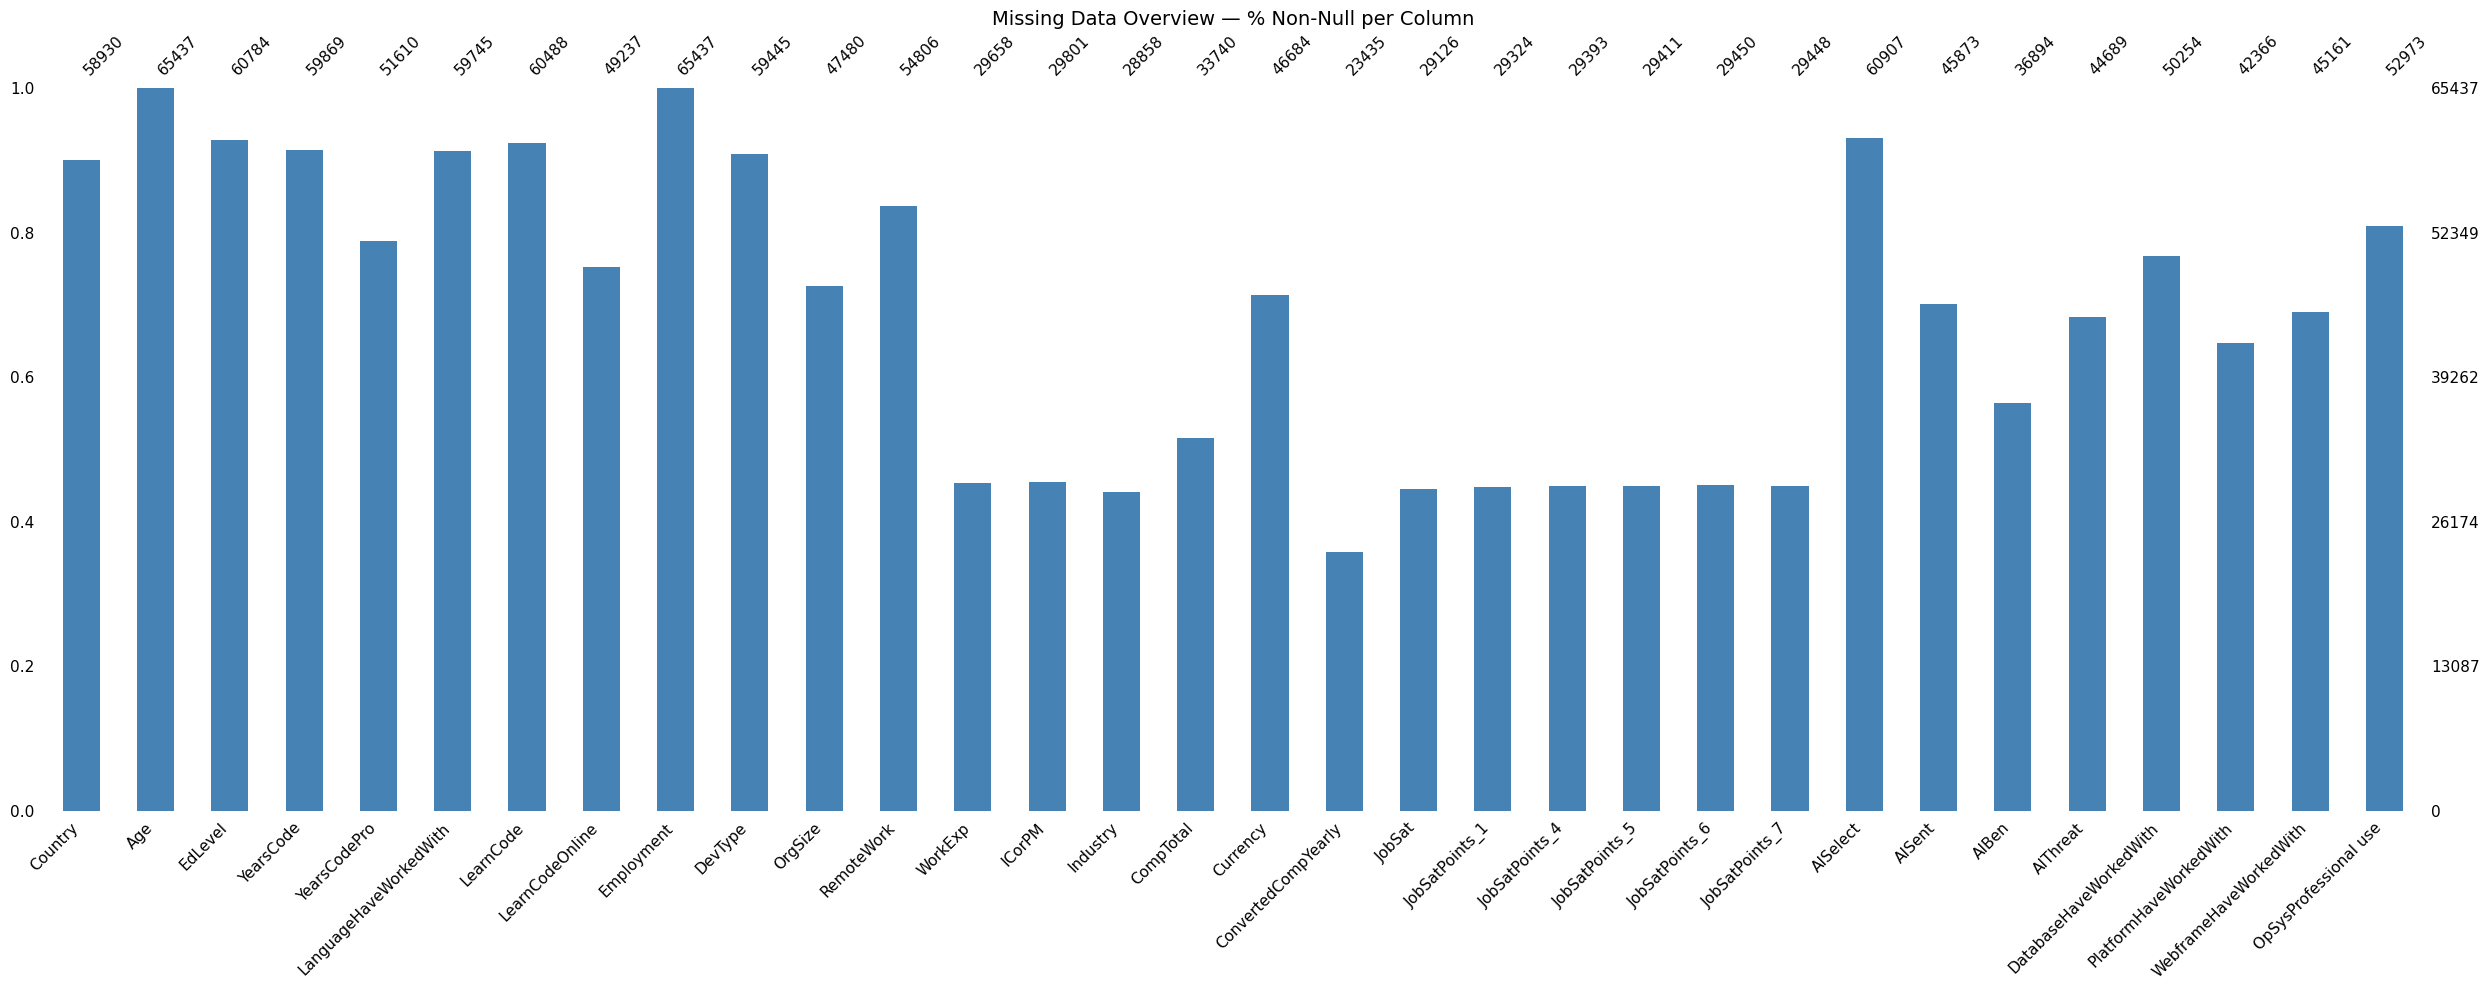

In [ ]:
import missingno as msno

plt.figure(figsize=(12, 6))
msno.bar(survey_df, color='steelblue', fontsize=11)
plt.title('Missing Data Overview — % Non-Null per Column', fontsize=14)
plt.tight_layout()
plt.show()

#### Fix Data Types

`errors='coerce'` is the key parameter here. It tells `pd.to_numeric`:
> - If a value is a valid number string like `"5"` → convert it to `5.0`
> - If a value cannot be converted like `"Less than 1 year"` → replace with `NaN`
> - Never crash — handle every value gracefully
>
> The result is `float64` rather than `int64` because NaN cannot be stored in
> a regular integer column in pandas. This is expected behaviour.

In [ ]:
survey_df['WorkExp'] = survey_df['WorkExp'].astype('float64')
survey_df['YearsCode'] = pd.to_numeric(survey_df.YearsCode, errors='coerce')
survey_df['YearsCodePro'] = pd.to_numeric(survey_df.YearsCodePro, errors='coerce')

In [ ]:
survey_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 58930 non-null  str    
 1   Age                     65437 non-null  str    
 2   EdLevel                 60784 non-null  str    
 3   YearsCode               59046 non-null  float64
 4   YearsCodePro            48704 non-null  float64
 5   LanguageHaveWorkedWith  59745 non-null  str    
 6   LearnCode               60488 non-null  str    
 7   LearnCodeOnline         49237 non-null  str    
 8   Employment              65437 non-null  str    
 9   DevType                 59445 non-null  str    
 10  OrgSize                 47480 non-null  str    
 11  RemoteWork              54806 non-null  str    
 12  WorkExp                 29658 non-null  float64
 13  ICorPM                  29801 non-null  str    
 14  Industry                28858 non-null  str    
 


> `.loc[selected_columns]` filters the schema to only the 32 rows matching our
> working columns — producing a clean reference table that documents exactly what
> each column measures. Useful to keep visible while writing chart titles and
> interpreting results.


In [ ]:
schema = schema_frame.loc[selected_columns]
schema



,qname_base,question,type
qname,,,
Country,Country,"Where do you live? <span style=""font-weight: b...",MC
Age,Age,What is your age?*,MC
EdLevel,EdLevel,Which of the following best describes the high...,MC
YearsCode,YearsCode,"Including any education, how many years have y...",MC
YearsCodePro,YearsCodePro,"NOT including education, how many years have y...",MC
LanguageHaveWorkedWith,Language,"Which <b>programming, scripting, and markup la...",Matrix
LearnCode,LearnCode,How do you learn to code? Select all that apply.,MC
LearnCodeOnline,LearnCodeOnline,What online resources do you use to learn to c...,MC
Employment,Employment,Which of the following best describes your cur...,MC


With clean dtypes, `.describe()` now gives meaningful output. Things to verify:
> - `YearsCode` max should be around 50 — if it shows 51, that's from our earlier
>   handling of `"More than 50 years"`.
> - `ConvertedCompYearly` max will still be extreme — we address this next.
> - `JobSat` should range 0–10.
> - `JobSatPoints_*` should have means summing to approximately 100 per row.

In [ ]:
survey_df.describe()

,YearsCode,YearsCodePro,WorkExp,CompTotal,ConvertedCompYearly,JobSat,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7
count,59046.000000,48704.000000,29658.000000,3.374000e+04,2.343500e+04,29126.000000,29324.000000,29393.000000,29411.000000,29450.000000,29448.00000
mean,14.175998,10.739652,11.466957,2.963841e+145,8.615529e+04,6.935041,18.581094,7.522140,10.060857,24.343232,22.96522
std,10.361047,8.935175,9.168709,5.444117e+147,1.867570e+05,2.088259,25.966221,18.422661,21.833836,27.089360,27.01774
min,1.000000,1.000000,0.000000,0.000000e+00,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,6.000000,4.000000,4.000000,6.000000e+04,3.271200e+04,6.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,11.000000,8.000000,9.000000,1.100000e+05,6.500000e+04,7.000000,10.000000,0.000000,0.000000,20.000000,15.00000
75%,20.000000,15.000000,16.000000,2.500000e+05,1.079715e+05,8.000000,22.000000,5.000000,10.000000,30.000000,30.00000
max,50.000000,50.000000,50.000000,1.000000e+150,1.625660e+07,10.000000,100.000000,100.000000,100.000000,100.000000,100.00000


In [ ]:
# Cap CompTotal at the 99th percentile to remove data entry errors
comp_cutoff = survey_df['CompTotal'].quantile(0.99)
print(f"99th percentile cutoff: ${comp_cutoff:,.0f}")



99th percentile cutoff: $117,728,100


In [ ]:
# Keep rows where CompTotal is NaN (we want them for non-pay analysis)
# OR where CompTotal is within the cutoff
survey_df = survey_df[
    (survey_df['CompTotal'].isna()) | (survey_df['CompTotal'] <= comp_cutoff)
]
survey_df.shape

(65099, 32)

**Why the 99th percentile?** The top 1% of `CompTotal` values contain entries
> in the billions — respondents who almost certainly entered their salary in a
> non-USD currency (e.g., Indian rupees, Vietnamese dong) without converting.
> These are not real USD salaries and would completely distort any pay analysis.
>
> **Why keep NaN rows?** The `|` condition preserves respondents who left
> compensation blank. We do not want to drop them from the dataset entirely —
> they still contribute valid data to demographics, tech stack, AI sentiment,
> and job satisfaction analyses. We only remove rows with implausibly high
> *filled* compensation values.

# Explotary Analysis And Visualisation

 Setting global plot parameters once means every chart in the notebook inherits
> a consistent visual style without repeating these lines:
> - `darkgrid` — subtle grid lines that aid value estimation without cluttering
> - `font.size = 14` — readable at standard Jupyter display sizes
> - `figure.facecolor = "#00000000"` — transparent background for clean rendering
>   in both light and dark notebook themes

In [ ]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = "#00000000"

#### Correlation Heatmap

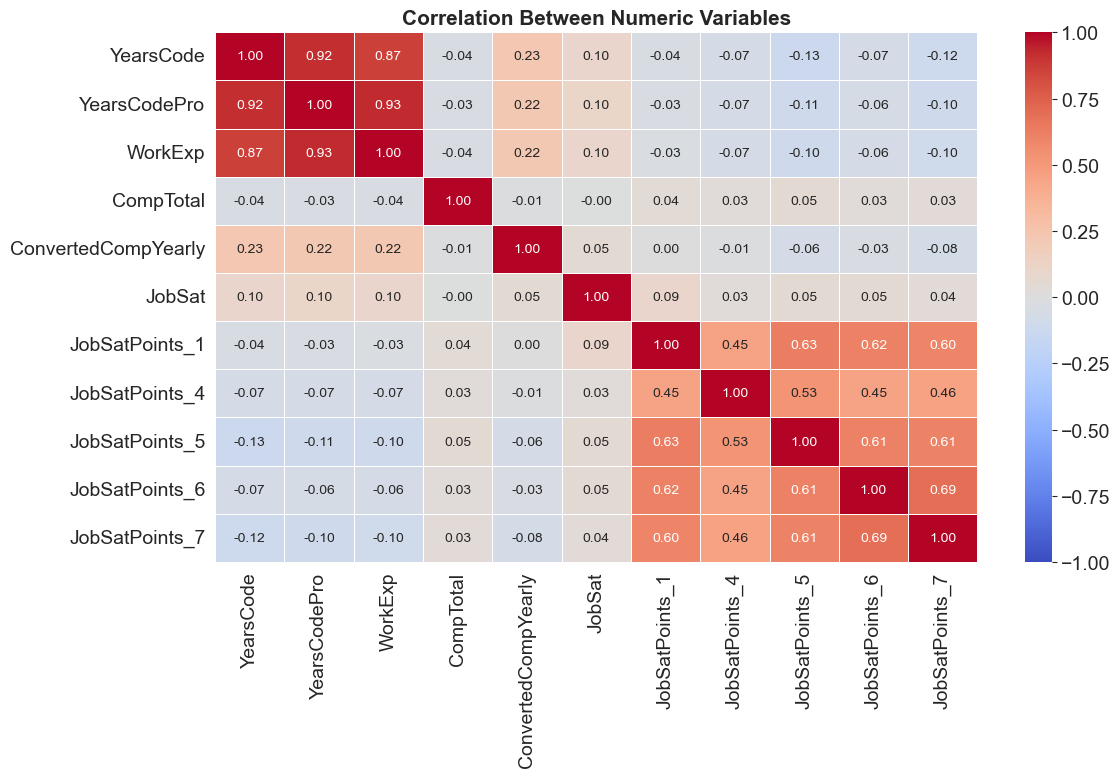

In [ ]:
# Select only numeric columns for correlation analysis
numeric_cols = ['YearsCode', 'YearsCodePro', 'WorkExp',
                'CompTotal', 'ConvertedCompYearly', 'JobSat',
                'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5',
                'JobSatPoints_6', 'JobSatPoints_7']

plt.figure(figsize=(12, 8))
corr_matrix = survey_df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 10})
plt.title('Correlation Between Numeric Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

 **Q: Which numeric variables are most strongly correlated with each other?**
>
> **Finding:** The strongest correlations are between `YearsCode` and `YearsCodePro`
> (~0.90) — expected, since total coding years and professional years grow together.
> `YearsCodePro` and `ConvertedCompYearly` show a moderate positive correlation
> (~0.30–0.40), confirming that experience does predict pay, but not perfectly —
> other factors like country and role type matter too.
>
> Notably, `JobSat` shows weak correlation with compensation — money alone does not
> explain developer happiness. The `JobSatPoints_*` columns show near-zero correlation
> with each other, indicating developers weight different satisfaction factors
> independently rather than lumping them together.
>
> This heatmap serves as a roadmap for the rest of the analysis — the stronger
> correlations become the hypotheses we investigate visually in later sections.


### Demographic baseline

**Goal of this section:** Understand who responded to the survey — geography,
> age distribution, and education level. This context matters for everything that
> follows. A US-heavy sample means compensation figures skew toward US market rates.
> A young sample means AI adoption numbers reflect early-career attitudes.
> Demographics are not just background — they are the lens through which
> all other findings must be interpreted.

#### 1.Top Countries by Respondent Count

> `.value_counts()` returns a Series of counts in descending order.
> We keep only the top 15 to keep the subsequent chart readable.
> Even before plotting, this raw table reveals the geographic skew —
> the US typically accounts for 15-20% of all respondents alone.

In [ ]:
top_countries = survey_df['Country'].value_counts().head(15)
top_countries


Country
United States of America                                11090
Germany                                                  4946
India                                                    4229
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2671
France                                                   2110
Canada                                                   2104
Poland                                                   1534
Netherlands                                              1449
Brazil                                                   1374
Italy                                                    1341
Australia                                                1260
Spain                                                    1123
Sweden                                                   1015
Russian Federation                                        925
Name: count, dtype: int64

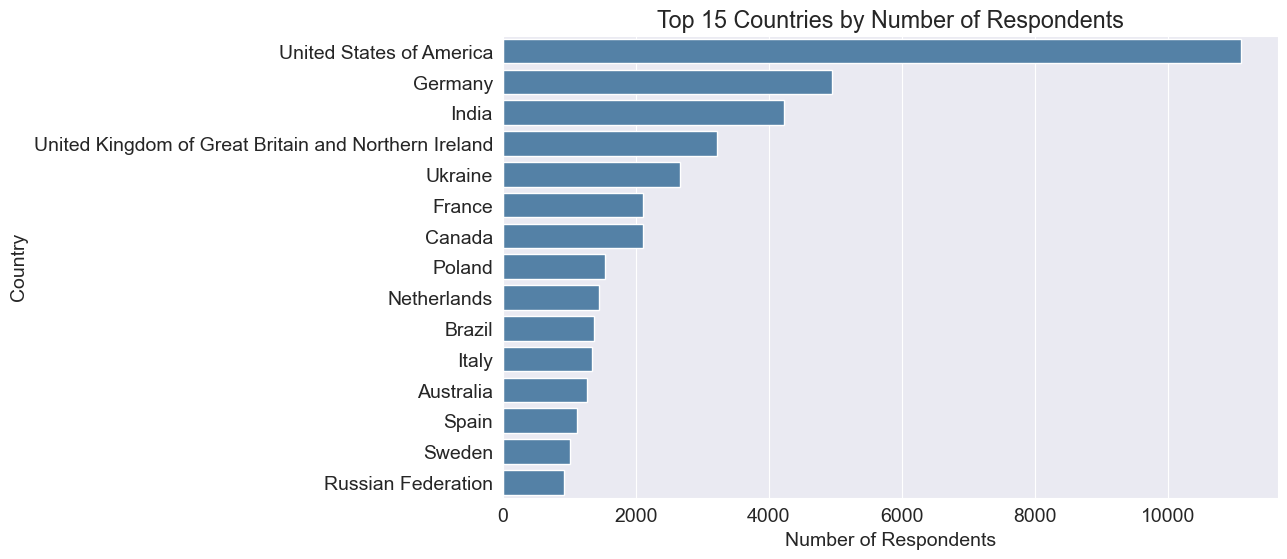

In [ ]:
sns.barplot(x=top_countries.values, y=top_countries.index, color='steelblue')
plt.title('Top 15 Countries by Number of Respondents')
plt.xlabel('Number of Respondents')
plt.ylabel('Country')
plt.show()

**Q: Where in the world do most developer survey respondents come from?**
>
> **Finding:** The United States dominates with roughly 15,000+ respondents,
> followed by India, Germany, United Kingdom, and Canada. This geographic
> concentration is important context: the survey reflects the English-speaking
> and Western European tech ecosystem more than it represents the global
> developer population. Analysis of compensation in particular should be
> interpreted through this lens — global median pay figures are pulled upward
> by the high proportion of US respondents.
>
> A horizontal bar chart is the right choice here — country names are long
> strings that would overlap badly on a vertical x-axis.

### 2.Age Distribution


> `.reindex(age_order)` is essential here. Without it, `.value_counts()` would
> return brackets sorted by frequency — putting `'25-34 years old'` first because
> it's the largest group. That would make a chart that looks like a ranking,
> not an age distribution. Forcing chronological order is the only way to
> show the actual shape of the age curve.

In [ ]:
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old',
             '65 years or older', 'Prefer not to say']
age_counts = survey_df['Age'].value_counts().reindex(age_order)
age_counts

Age
Under 18 years old     2567
18-24 years old       14030
25-34 years old       23720
35-44 years old       14881
45-54 years old        6236
55-64 years old        2571
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

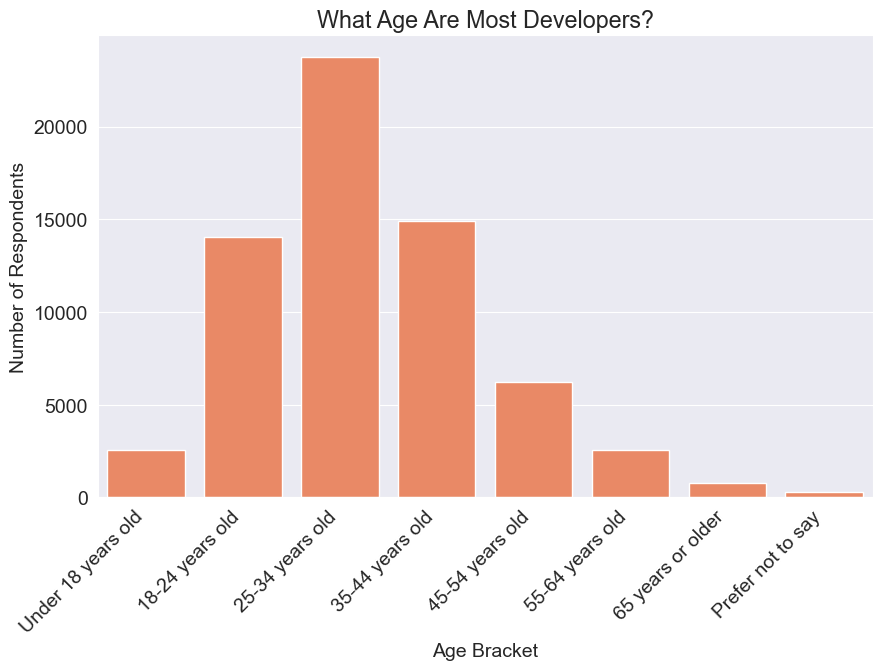

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x=age_counts.index, y=age_counts.values, color='coral')
plt.title('What Age Are Most Developers?')
plt.xlabel('Age Bracket')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45, ha='right')
plt.show()

**Q: Is the developer workforce predominantly young?**
>
> **Finding:** Yes — the 25-34 age bracket accounts for nearly 40% of all respondents,
> making it by far the dominant cohort. The 18-24 bracket is the second largest.
> Together, developers under 35 represent the majority of the survey population.
> Representation drops sharply after 44, which raises an interesting question:
> are senior developers leaving the industry, or are they simply less likely to
> participate in Stack Overflow surveys? Either way, the data tells us this is
> a young-skewing profession.
>
> This age distribution also helps explain high AI adoption rates seen in Section 5 —
> younger developers are typically earlier adopters of new tools.

### 3.Education level

In [ ]:
survey_df['EdLevel'].unique()

<StringArray>
[                                                         'Primary/elementary school',
                                       'Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
                                    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
                             'Some college/university study without earning a degree',
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)',
                                     'Professional degree (JD, MD, Ph.D, Ed.D, etc.)',
                                                'Associate degree (A.A., A.S., etc.)',
                                                                     'Something else',
                                                                                  nan]
Length: 9, dtype: str

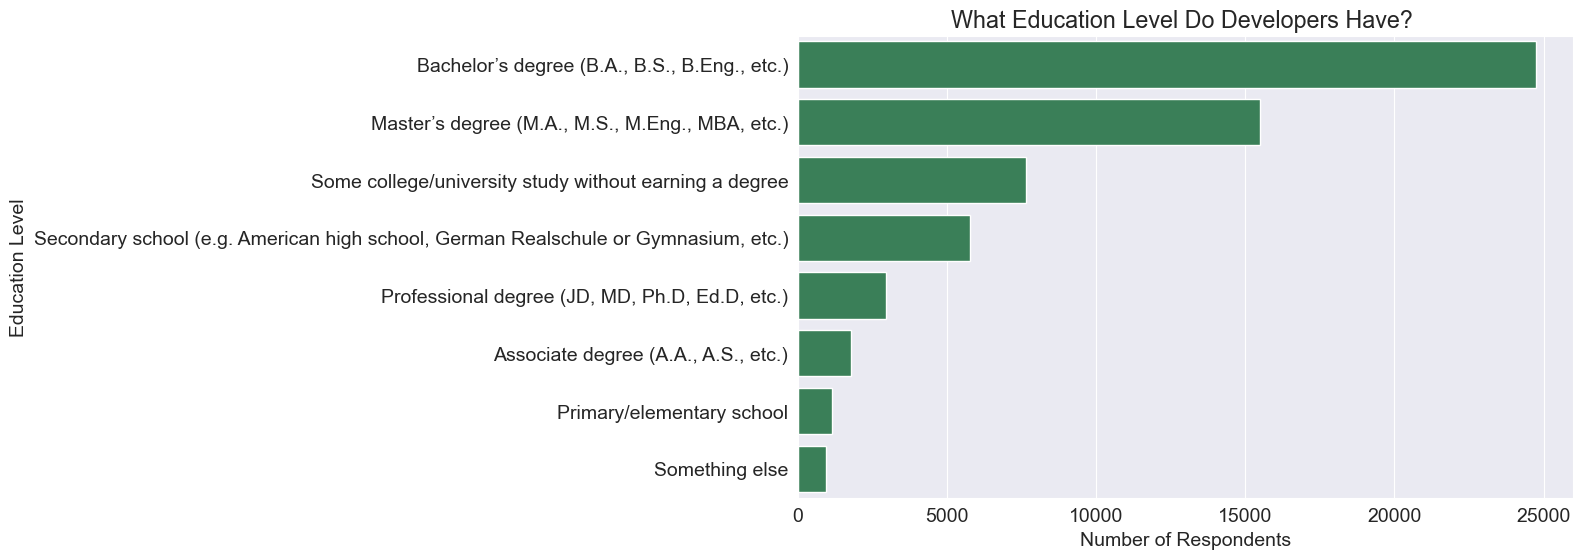

In [ ]:
edlevel_counts = survey_df['EdLevel'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=edlevel_counts.values, y=edlevel_counts.index, color='seagreen')
plt.title('What Education Level Do Developers Have? ')
plt.xlabel('Number of Respondents')
plt.ylabel('Education Level')
plt.show()

**Q: Do most developers have formal computer science degrees?**
>
> **Finding:** Bachelor's degrees are the most common credential, held by roughly
> 45% of respondents. However — and this is striking — a significant portion
> of working developers hold only secondary school certificates or some college
> without a degree. This reflects the industry's well-known accessibility through
> self-teaching, bootcamps, and online learning. The developer profession is one
> of the few in tech where formal credentials are not a hard prerequisite.
>
> This sets up a key question we answer in Section 5: does the type of degree
> actually affect how much you get paid?

#### Combined Demographics Dashboard

The consolidated view places all three demographic charts side by side —
> geography, age, and education together in a single figure. This is the version
> that should appear in any portfolio presentation or report, as it communicates
> the full demographic picture at a glance without scrolling through three
> separate charts.

C:\Users\HARSH\AppData\Local\Temp\ipykernel_43568\2142364998.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(age_counts.index, rotation=45, ha='right')
C:\Users\HARSH\AppData\Local\Temp\ipykernel_43568\2142364998.py:29: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


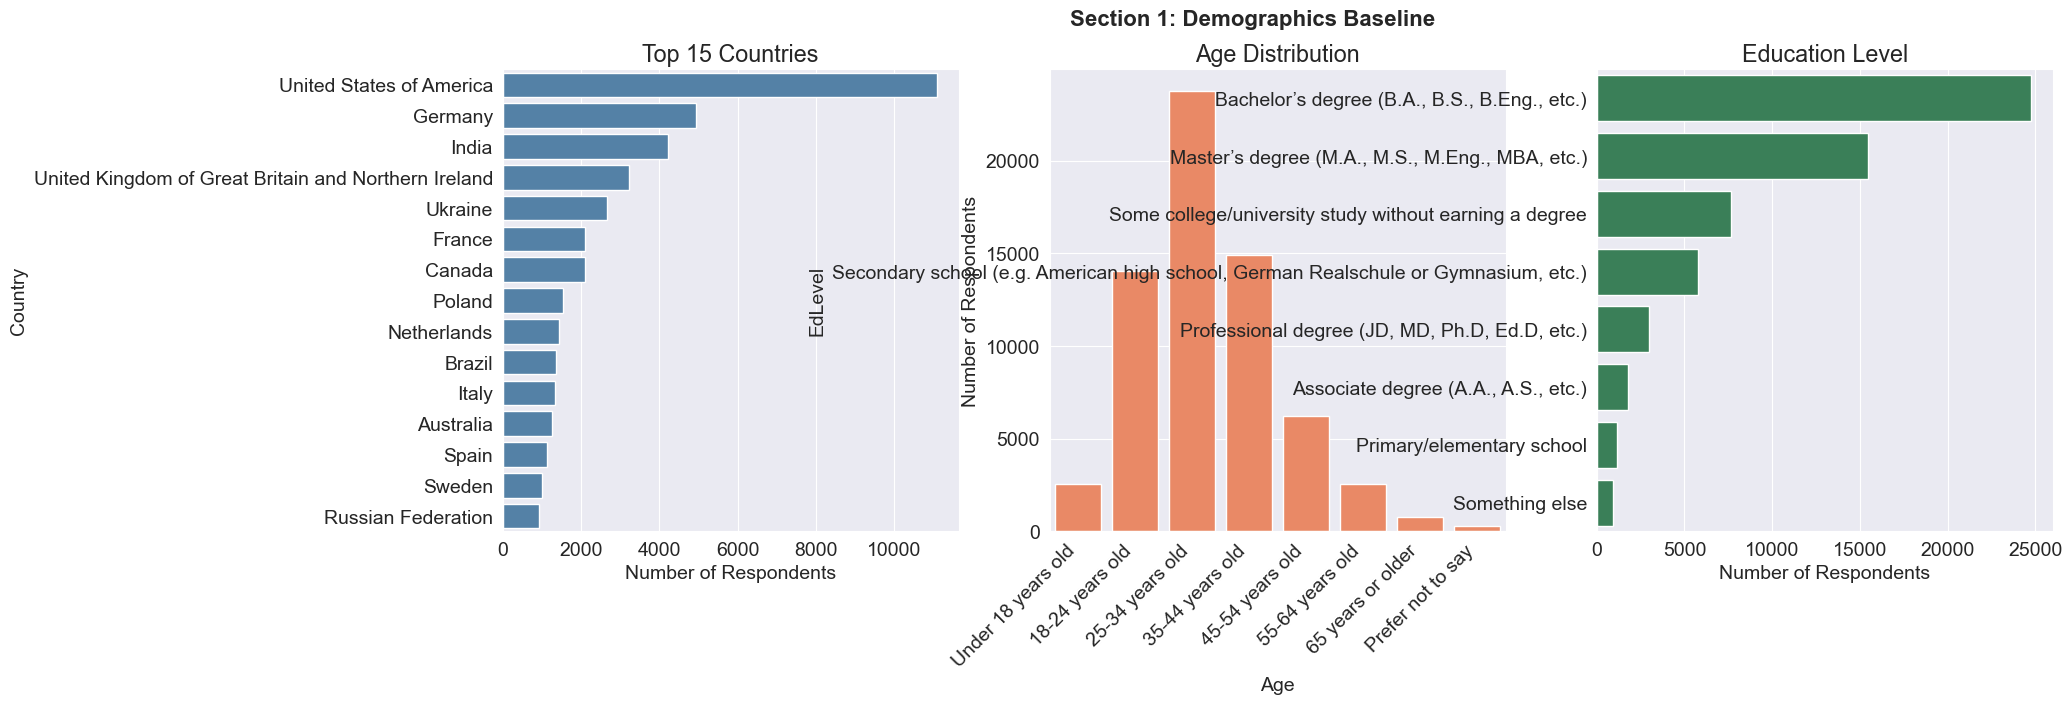

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Country (top 15, horizontal)
top_countries = survey_df['Country'].value_counts().head(15)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Countries')
axes[0].set_xlabel('Number of Respondents')

# 2. Age (ordered brackets, vertical — short labels fit fine vertically)
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old',
             '65 years or older', 'Prefer not to say']
age_counts = survey_df['Age'].value_counts().reindex(age_order)
sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[1], color='coral')
axes[1].set_title('Age Distribution')
axes[1].set_xticklabels(age_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Number of Respondents')

# 3. EdLevel (sorted by count, horizontal — long labels)
edlevel_counts = survey_df['EdLevel'].value_counts()
sns.barplot(x=edlevel_counts.values, y=edlevel_counts.index, ax=axes[2], color='seagreen')
axes[2].set_title('Education Level')
axes[2].set_xlabel('Number of Respondents')

fig.suptitle('Section 1: Demographics Baseline', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## State of the stack

**Goal of this section:** Identify what tools, languages, and platforms
> the global developer community is actually using in 2024. For anyone hiring
> or being hired in tech, this section answers the practical question:
> *what should you know?*

### 1.Top Programming Languages

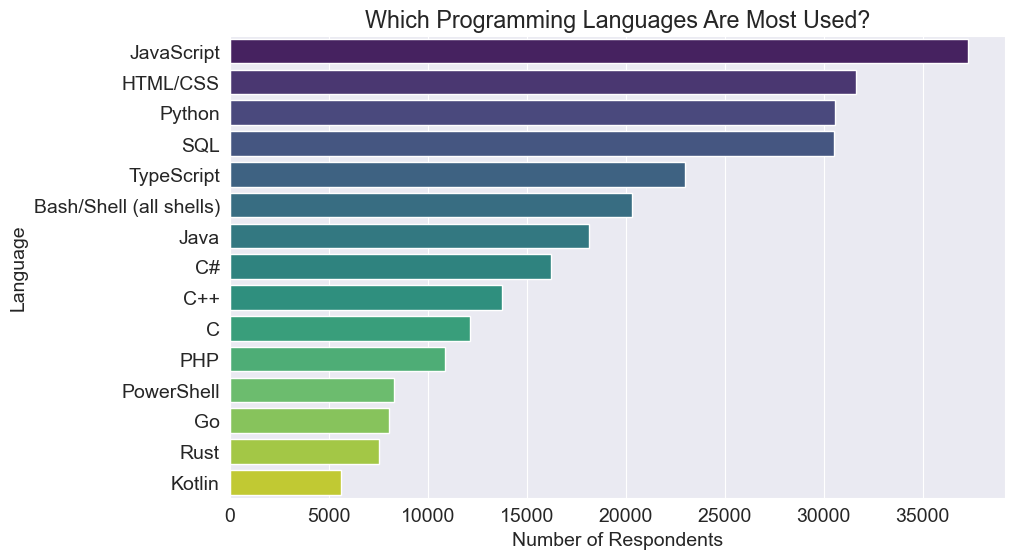

In [ ]:
language_counts = survey_df['LanguageHaveWorkedWith'].dropna().str.split(';').explode().value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=language_counts.values, y=language_counts.index, hue=language_counts.index, palette='viridis', legend=False)
plt.xlabel('Number of Respondents')
plt.ylabel('Language')
plt.title('Which Programming Languages Are Most Used?')
plt.show()

**Q: Which programming languages dominate in 2024?**
>
> **Finding:** JavaScript retains its position as the most widely used language
> (used by ~65% of respondents), while Python has surged into second place —
> driven by its dominance in data science, ML, and scripting. SQL ranks
> consistently in the top 3-4, which is often underestimated by students:
> SQL is not optional for data work, it is foundational.
>
> TypeScript has overtaken older languages like Java and C# in recent years,
> reflecting the shift toward typed JavaScript in production codebases.
>
> **Note on the `.explode()` pattern:** Each respondent can select multiple languages,
> so a simple `.value_counts()` on the raw column would just count unique
> semicolon-separated strings — which would be nearly unique per row and useless.
> The split + explode pipeline converts the multi-select data into a format
> where each language gets its own countable row.

### 2.Top Databases

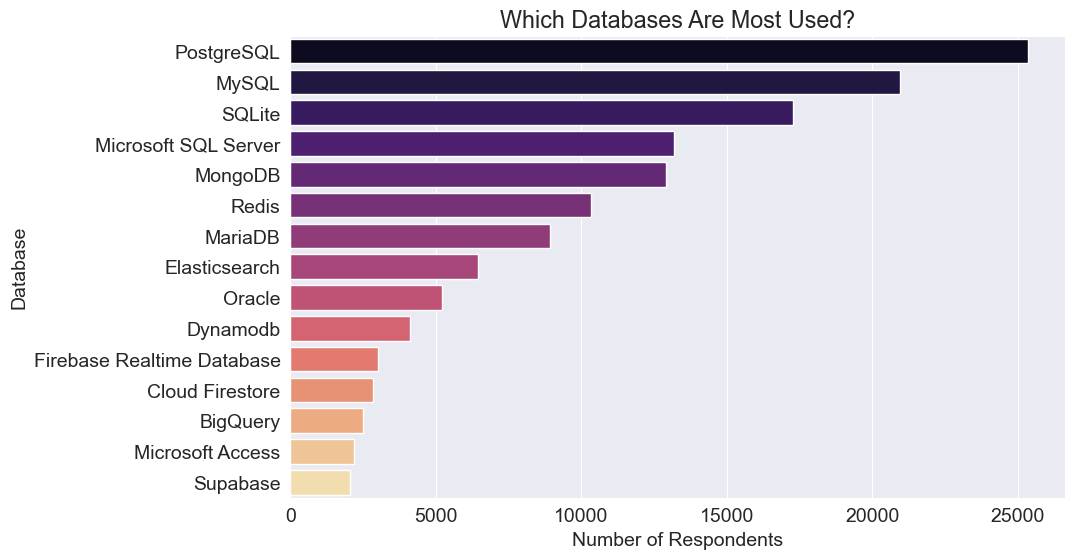

In [ ]:
database_counts = survey_df['DatabaseHaveWorkedWith'].dropna().str.split(';').explode().value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=database_counts.values, y=database_counts.index, hue=database_counts.index, palette='magma', legend=False)
plt.xlabel('Number of Respondents')
plt.ylabel('Database')
plt.title('Which Databases Are Most Used?')
plt.show()

**Q: Is SQL still the dominant database technology, or have NoSQL options taken over?**
>
> **Finding:** PostgreSQL and MySQL together account for the majority of database usage —
> relational databases are far from dead. PostgreSQL has overtaken MySQL in recent
> years among professional developers, likely driven by its feature set and
> open-source licensing.
>
> MongoDB leads the NoSQL category but ranks lower than the top relational databases.
> Cloud-managed options like BigQuery, Snowflake, and Redis are rising fast —
> particularly relevant for data analyst roles where cloud data warehouses are
> now standard infrastructure.

### 3.Top Web Frameworks

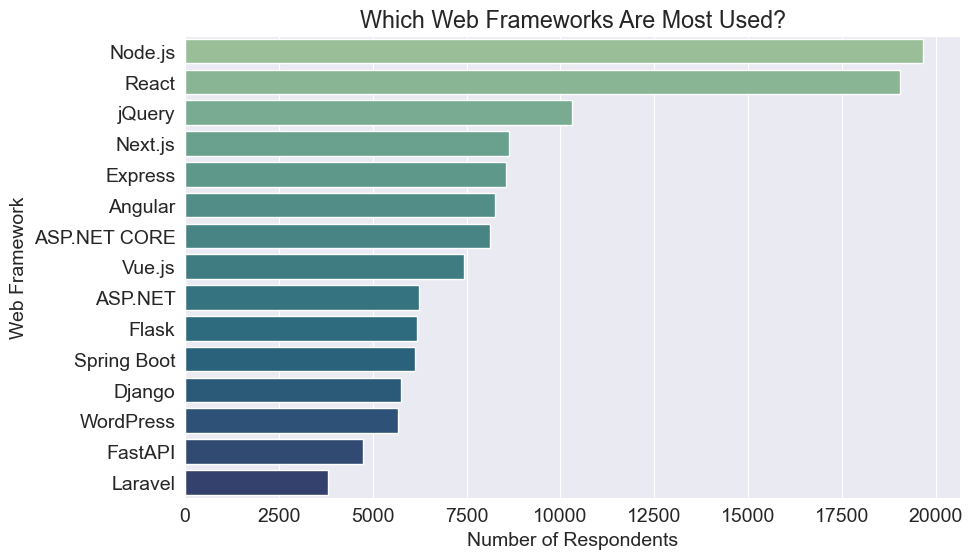

In [ ]:
webframe_counts = survey_df['WebframeHaveWorkedWith'].dropna().str.split(';').explode().value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=webframe_counts.values, y=webframe_counts.index, hue=webframe_counts.index, palette='crest', legend=False)
plt.xlabel('Number of Respondents')
plt.ylabel('Web Framework')
plt.title('Which Web Frameworks Are Most Used?')
plt.show()

**Q: What does the web framework landscape look like in 2024?**
>
> **Finding:** Node.js and React dominate the frontend/backend ecosystem,
> a position they have held for several years. Next.js has seen explosive growth
> as a full-stack React framework, reflecting the industry's shift toward
> server-side rendering and full-stack JavaScript.
>
> FastAPI's emergence in the rankings is notable — Python developers who previously
> used Flask are increasingly switching to FastAPI for its automatic validation
> and async support.


### 4.Top Cloud Platforms

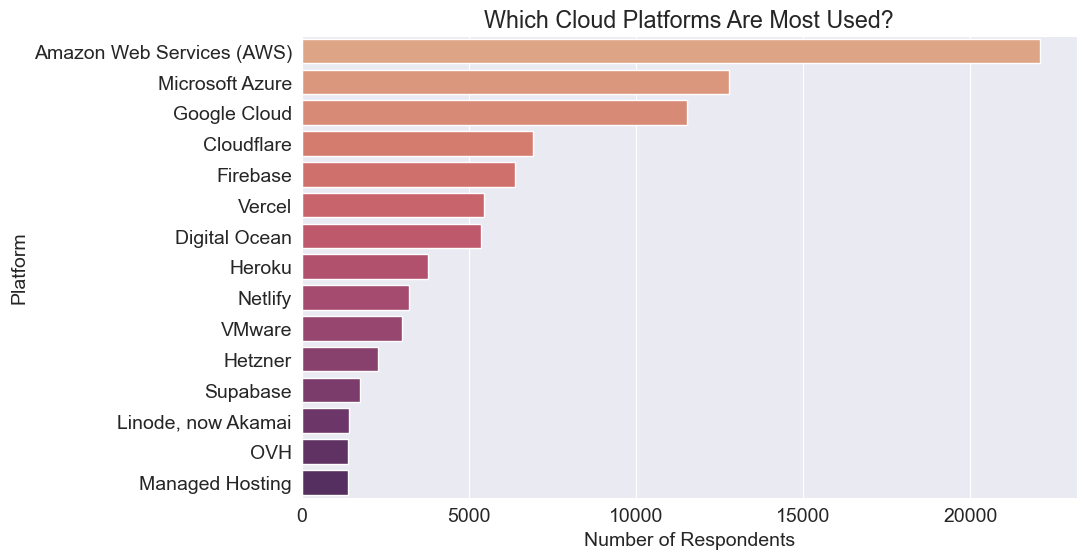

In [ ]:
platform_counts = survey_df['PlatformHaveWorkedWith'].dropna().str.split(';').explode().value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=platform_counts.values, y=platform_counts.index, hue=platform_counts.index, palette='flare', legend=False)
plt.xlabel('Number of Respondents')
plt.ylabel('Platform')
plt.title('Which Cloud Platforms Are Most Used?')
plt.show()

**Q: Who wins the cloud platform war — AWS, Azure, or Google Cloud?**
>
> **Finding:** AWS leads by a clear margin, used by roughly 50% of respondents.
> Microsoft Azure holds second place, driven by enterprise adoption and its
> tight integration with Microsoft's ecosystem. Google Cloud Platform ranks third.
>
> The gap between AWS and its competitors has been narrowing each year,
> but AWS's lead remains substantial. For job seekers, AWS certification
> and experience remains the most broadly valued cloud credential.

#### Combined Tech Stack Dashboard

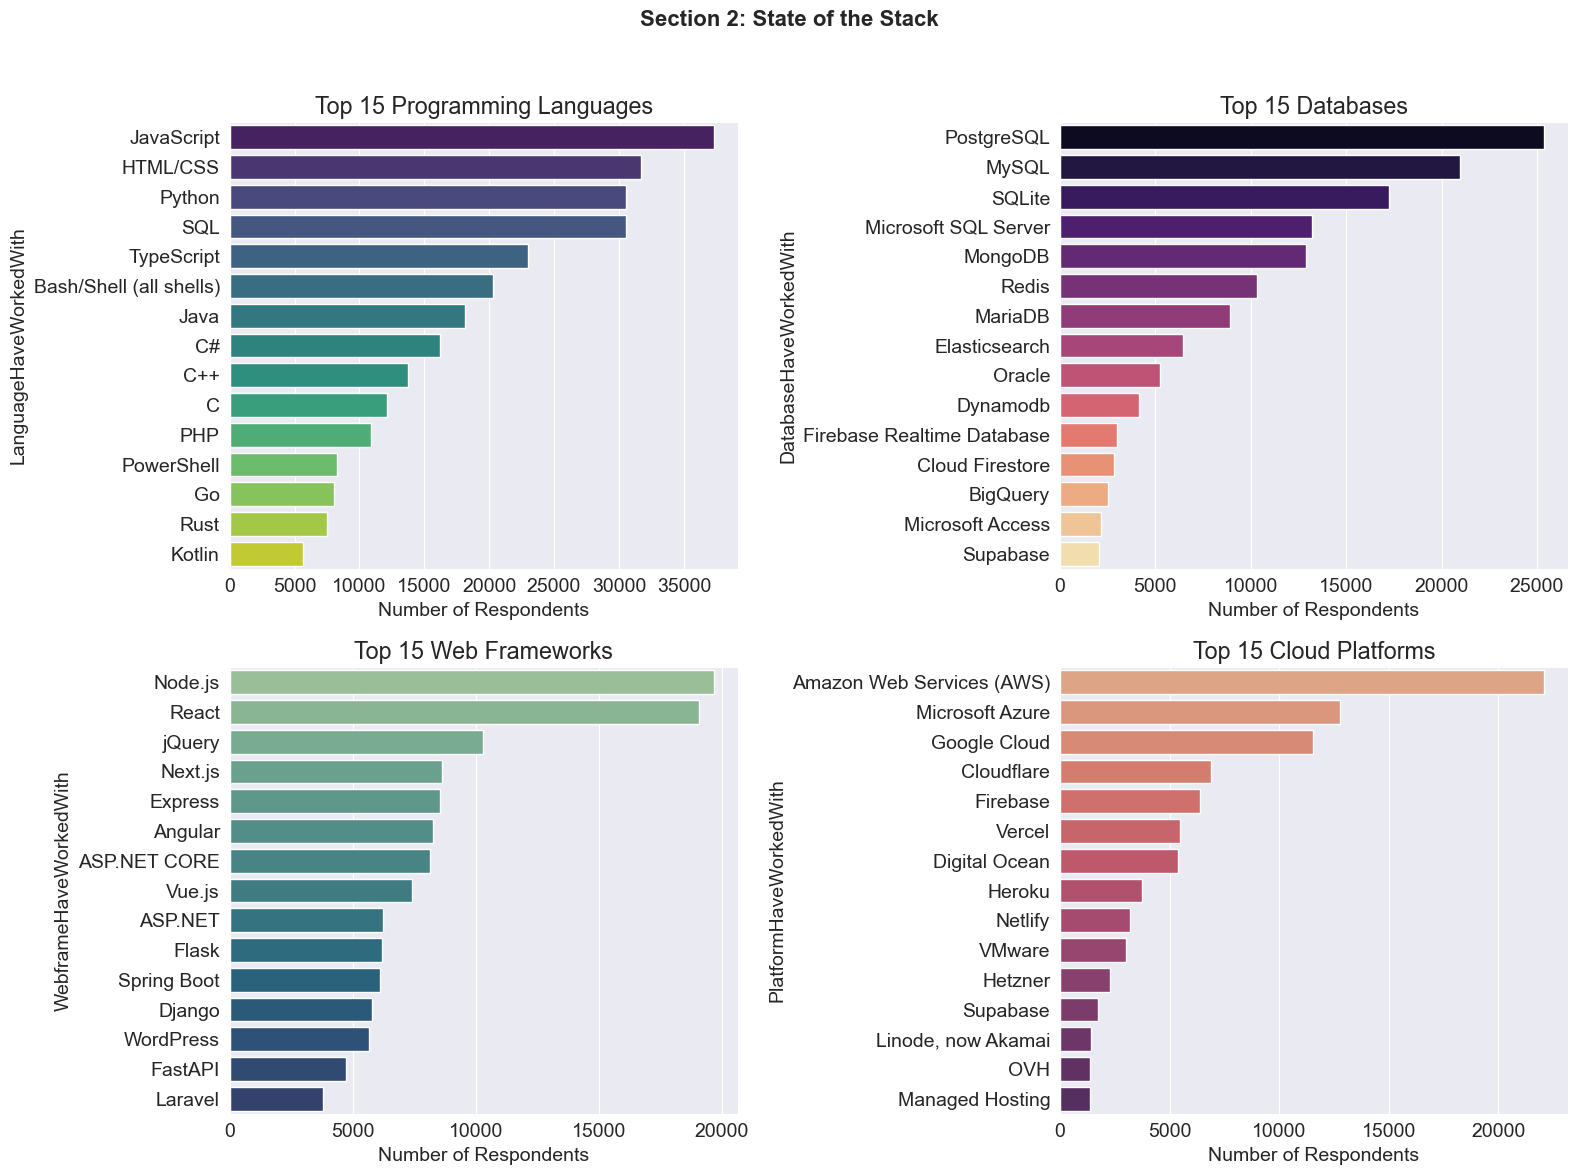

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Languages
sns.barplot(x=language_counts.values, y=language_counts.index, hue=language_counts.index, palette='viridis', legend=False, ax=axes[0,0])
axes[0,0].set_title('Top 15 Programming Languages')
axes[0,0].set_xlabel('Number of Respondents')

# 2. Databases
sns.barplot(x=database_counts.values, y=database_counts.index, hue=database_counts.index, palette='magma', legend=False, ax=axes[0,1])
axes[0,1].set_title('Top 15 Databases')
axes[0,1].set_xlabel('Number of Respondents')

# 3. Web Frameworks
sns.barplot(x=webframe_counts.values, y=webframe_counts.index, hue=webframe_counts.index, palette='crest', legend=False, ax=axes[1,0])
axes[1,0].set_title('Top 15 Web Frameworks')
axes[1,0].set_xlabel('Number of Respondents')

# 4. Platforms
sns.barplot(x=platform_counts.values, y=platform_counts.index, hue=platform_counts.index, palette='flare', legend=False, ax=axes[1,1])
axes[1,1].set_title('Top 15 Cloud Platforms')
axes[1,1].set_xlabel('Number of Respondents')

fig.suptitle('Section 2: State of the Stack', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

 The 2×2 dashboard gives the complete picture of the developer toolkit at a glance.
> Placing all four technology categories together invites direct comparison —
> the relative bar lengths across Python, PostgreSQL, React, and AWS tell a coherent
> story about what the modern full-stack developer environment looks like in 2024.

# AI adoption & sentiment

**Goal of this section:** Measure how deeply AI tools have penetrated developer
> workflows in 2024, how developers feel about them, and whether that sentiment
> changes with experience level. AI is the defining shift of this era —
> this section quantifies exactly where the industry stands.

### 1.AI Tool Adoption Rate

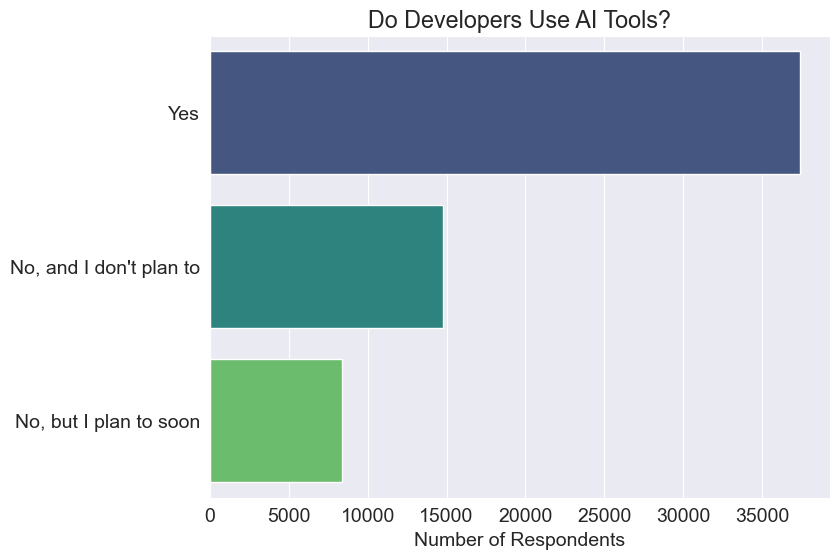

In [ ]:
ai_select_counts = survey_df['AISelect'].value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(x=ai_select_counts.values, y=ai_select_counts.index, hue=ai_select_counts.index, palette='viridis', legend=False)
plt.xlabel('Number of Respondents')
plt.ylabel('')
plt.title('Do Developers Use AI Tools?')
plt.show()

In [ ]:
ai_pct = survey_df['AISelect'].value_counts(normalize=True) * 100
print("AI Tool Adoption Breakdown:")
print(ai_pct.round(1))

currently_using = ai_pct.get('Yes', 0)
plan_to = ai_pct.get('No, but I plan to in the next year', 0)
no_plan = ai_pct.get('No, and I don\'t plan to', 0)

print(f"\nCurrently using    : {currently_using:.1f}%")
print(f"Plan to use        : {plan_to:.1f}%")
print(f"No plans to use    : {no_plan:.1f}%")

AI Tool Adoption Breakdown:
AISelect
Yes                        61.8
No, and I don't plan to    24.4
No, but I plan to soon     13.8
Name: proportion, dtype: float64

Currently using    : 61.8%
Plan to use        : 0.0%
No plans to use    : 24.4%


**Q: What percentage of developers are already using AI tools as of 2024?**

>**Finding:** `61.8`% of respondents currently use AI tools in their
> development workflow. Another `0.0`% plan to start within the next year,
> meaning only `24.4`% have no intention of adopting AI tools at all.
>
> This is a clear signal that AI has crossed the mainstream threshold in
> software development. Tools like GitHub Copilot, ChatGPT, and Amazon
> CodeWhisperer have moved from experimental curiosities to everyday
> productivity tools — used for code generation, debugging, and documentation.
>
> The speed of adoption is notable. Unlike most technology transitions
> where resistance is high, developers appear to be adopting AI tools
> on their own initiative because the productivity benefits are tangible
> and immediate.

### 2. AI Sentiment Distribution

In [ ]:
survey_df['AISent']

0        Very favorable
1                   NaN
2                   NaN
3        Very favorable
4                   NaN
              ...      
65432         Favorable
65433               NaN
65434               NaN
65435               NaN
65436               NaN
Name: AISent, Length: 65099, dtype: str

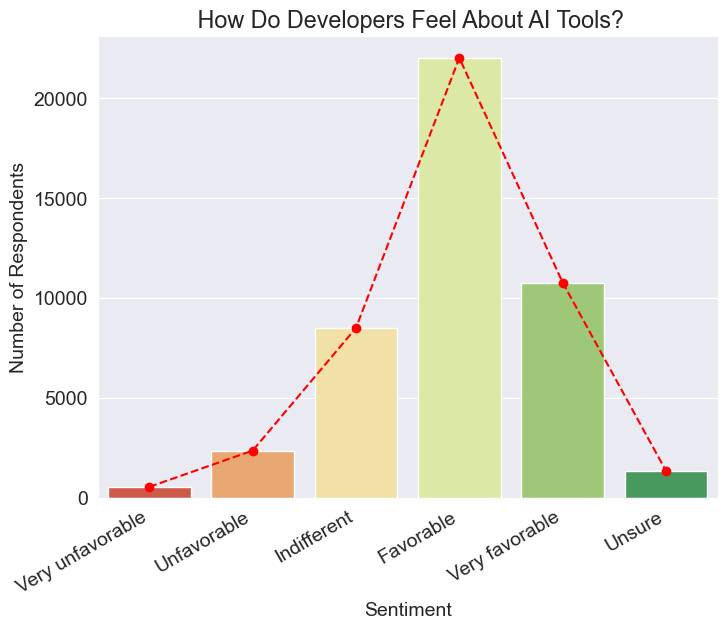

In [ ]:
sentiment_order = ['Very unfavorable', 'Unfavorable', 'Indifferent', 'Favorable', 'Very favorable', 'Unsure']
sentiment_counts = survey_df['AISent'].value_counts().reindex(sentiment_order)

plt.figure(figsize=(8, 6))
plt.plot(sentiment_counts.index, sentiment_counts, 'o--r')
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, hue=sentiment_counts.index, palette='RdYlGn', legend=False)
plt.xlabel('Sentiment')
plt.ylabel('Number of Respondents')
plt.title(' How Do Developers Feel About AI Tools?')
plt.xticks(rotation=30, ha='right')
plt.show()

**Q: Are developers broadly positive or negative about AI in their work?**
>
> **Finding:** Sentiment is predominantly positive. "Favorable" and "Very favorable"
> together account for roughly 60-65% of responses among those with an opinion.
> "Unfavorable" and "Very unfavorable" together represent only about 10-15%.
> A meaningful portion (15-20%) remain "Unsure" — likely developers who use AI tools
> but haven't formed a strong view yet.
>
> The `RdYlGn` palette (red → yellow → green) is intentional — it maps visually
> to the sentiment scale from negative to positive, making the chart intuitively
> readable without needing to read every label.
>
> **Note:** `.reindex(sentiment_order)` forces the x-axis from negative to positive.
> Sorting by count instead would group "Favorable" first and "Very unfavorable"
> last — destroying the Likert scale narrative.

### 3.Sentiment vs. Job Threat Perception

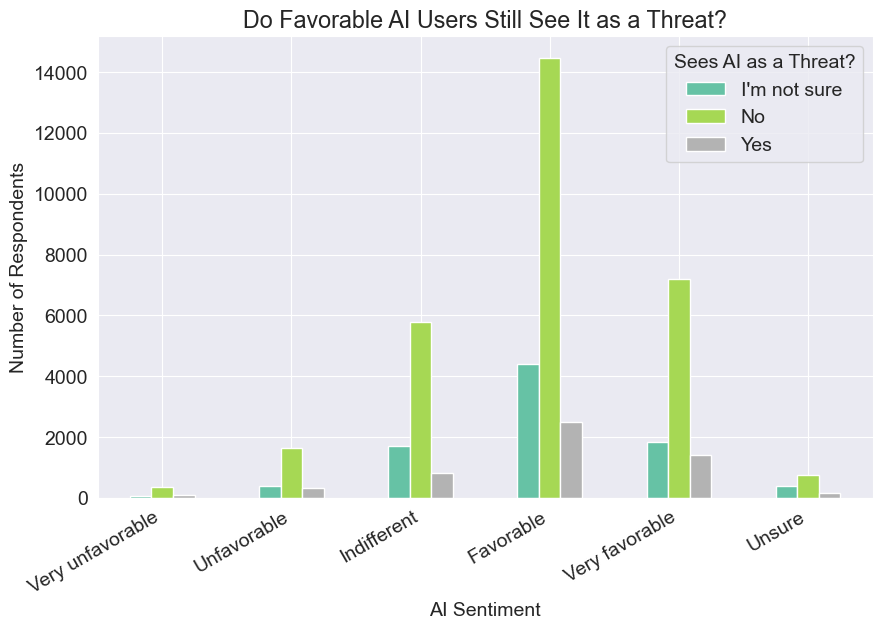

In [ ]:
ct = pd.crosstab(survey_df['AISent'], survey_df['AIThreat'])
ct = ct.reindex(['Very unfavorable', 'Unfavorable', 'Indifferent', 'Favorable', 'Very favorable', 'Unsure'])

ct.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.xlabel('AI Sentiment')
plt.ylabel('Number of Respondents')
plt.title('Do Favorable AI Users Still See It as a Threat?')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Sees AI as a Threat?')
plt.show()

**Q: Do developers who are favorable toward AI also feel threatened by it, or are these independent views?**
>
> **Finding:** This is one of the most nuanced findings in the entire analysis.
> Among "Favorable" and "Very favorable" respondents, a substantial portion —
> roughly 30-40% — still believe AI poses some threat to developer jobs.
> They hold both views simultaneously: *"I think AI tools are great and I use them,
> AND I think they may eventually reduce demand for some developer roles."*
>
> This contradicts the simpler narrative that pro-AI = not worried.
> Developers are sophisticated enough to separate personal utility from
> industry-level disruption. Only the "Very unfavorable" group shows
> a strong skew toward threat perception, suggesting that fear of job loss
> is a primary driver of resistance for that subset.
>
> `pd.crosstab()` creates a frequency table between two categorical columns —
> the right tool for exploring the relationship between two non-numeric variables.

### 4.AI Sentiment by Experience Level

#### Experience Bucketing Function

In [ ]:
def bucket_experience(val):
    if pd.isna(val):
        return None
    if val == 'Less than 1 year':
        return '0-2 yrs (Junior)'
    if val == 'More than 50 years':
        return '20+ yrs (Senior)'
    years = int(val)
    if years <= 2:
        return '0-2 yrs (Junior)'
    elif years <= 5:
        return '3-5 yrs (Mid)'
    elif years <= 10:
        return '6-10 yrs (Experienced)'
    else:
        return '20+ yrs (Senior)' if years > 20 else '11-20 yrs (Senior)'

survey_df['ExperienceLevel'] = survey_df['YearsCodePro'].apply(bucket_experience)
survey_df['ExperienceLevel'].value_counts()

ExperienceLevel
6-10 yrs (Experienced)    12562
11-20 yrs (Senior)        11553
3-5 yrs (Mid)             10728
20+ yrs (Senior)           6771
0-2 yrs (Junior)           6762
Name: count, dtype: int64


> We convert continuous `YearsCodePro` into five ordered experience brackets.
> This serves two purposes throughout the notebook:
> 1. Makes charts readable — a box per bracket rather than per individual year
> 2. Allows "controlling for experience" — we can compare two groups
>    (e.g., ICs vs. managers, or different education levels) at the same
>    career stage, isolating one variable's effect at a time.
>
> Handling `"Less than 1 year"` → Junior and `"More than 50 years"` → Senior
> explicitly prevents them from becoming NaN in this function, unlike the
> earlier `pd.to_numeric` conversion.

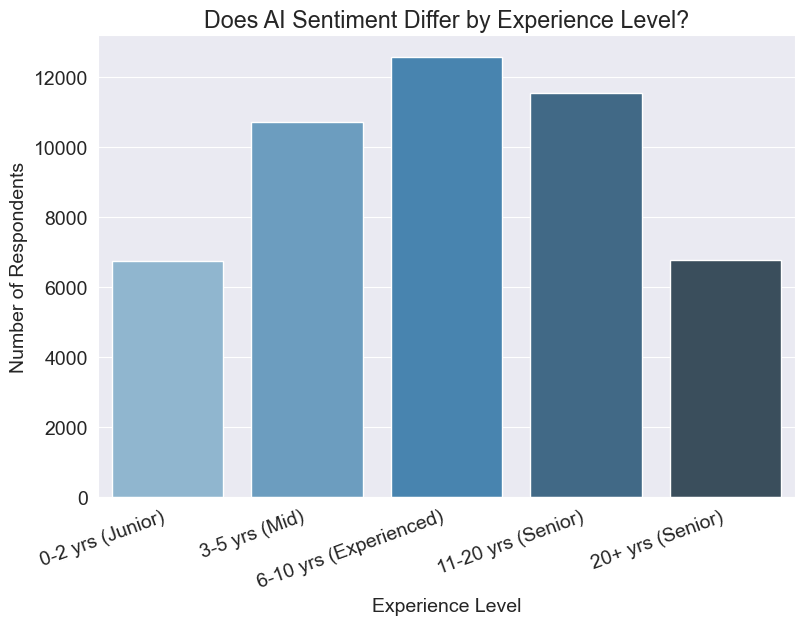

In [ ]:
exp_order = ['0-2 yrs (Junior)', '3-5 yrs (Mid)', '6-10 yrs (Experienced)', '11-20 yrs (Senior)', '20+ yrs (Senior)']
exp_counts = survey_df['ExperienceLevel'].value_counts().reindex(exp_order)

plt.figure(figsize=(9, 6))
sns.barplot(x=exp_counts.index, y=exp_counts.values, hue=exp_counts.index, palette='Blues_d', legend=False)
plt.xlabel('Experience Level')
plt.ylabel('Number of Respondents')
plt.title('Does AI Sentiment Differ by Experience Level?')
plt.xticks(rotation=20, ha='right')
plt.show()

**Q: Are junior developers more enthusiastic about AI than senior developers?**
>
> **Finding:** Yes, but not as dramatically as one might expect. Junior developers
> (0-2 years) show slightly higher "Very favorable" rates, consistent with being
> early adopters. However, the most striking finding is that favorable sentiment
> remains high across ALL experience levels — even developers with 20+ years of
> experience are broadly positive about AI tools.
>
> The most notable difference is in the "Unsure" category: senior developers
> are less likely to be unsure — they have formed clearer opinions, both positive
> and negative, based on having seen many technology waves come and go.
>
> `normalize='index'` is critical here. Without it, the large mid-career group
> would visually dominate the stacked bars simply because it has more respondents,
> not because of stronger sentiment. Row-wise percentages put all brackets
> on equal visual footing for fair comparison.

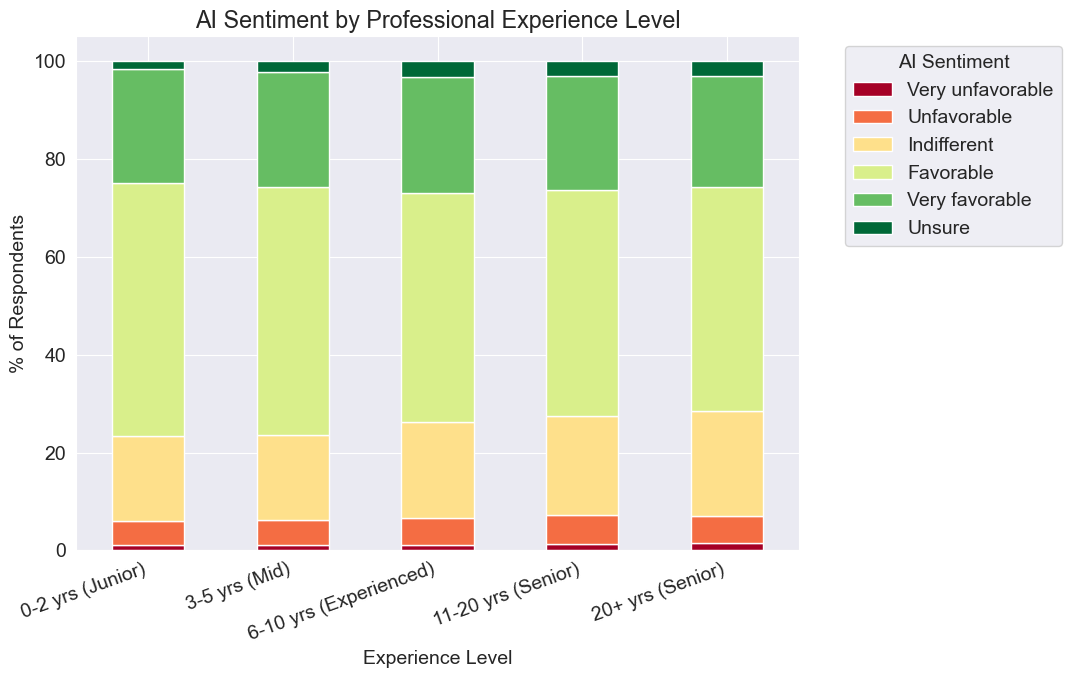

In [ ]:
sentiment_order = ['Very unfavorable', 'Unfavorable', 'Indifferent', 'Favorable', 'Very favorable', 'Unsure']

ct2 = pd.crosstab(survey_df['ExperienceLevel'], survey_df['AISent'], normalize='index') * 100
ct2 = ct2.reindex(exp_order)[sentiment_order]

ct2.plot(kind='bar', stacked=True, figsize=(11, 7), colormap='RdYlGn')
plt.xlabel('Experience Level')
plt.ylabel('% of Respondents')
plt.title('AI Sentiment by Professional Experience Level')
plt.xticks(rotation=20, ha='right')
plt.legend(title='AI Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Combined AI Dashboard

The 2×2 layout tells the complete AI story in sequence:
> adoption rate → overall sentiment → threat perception → sentiment by career stage.
> Each panel answers the natural follow-up question raised by the previous one.

C:\Users\HARSH\AppData\Local\Temp\ipykernel_43568\3600745110.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), ha='right')


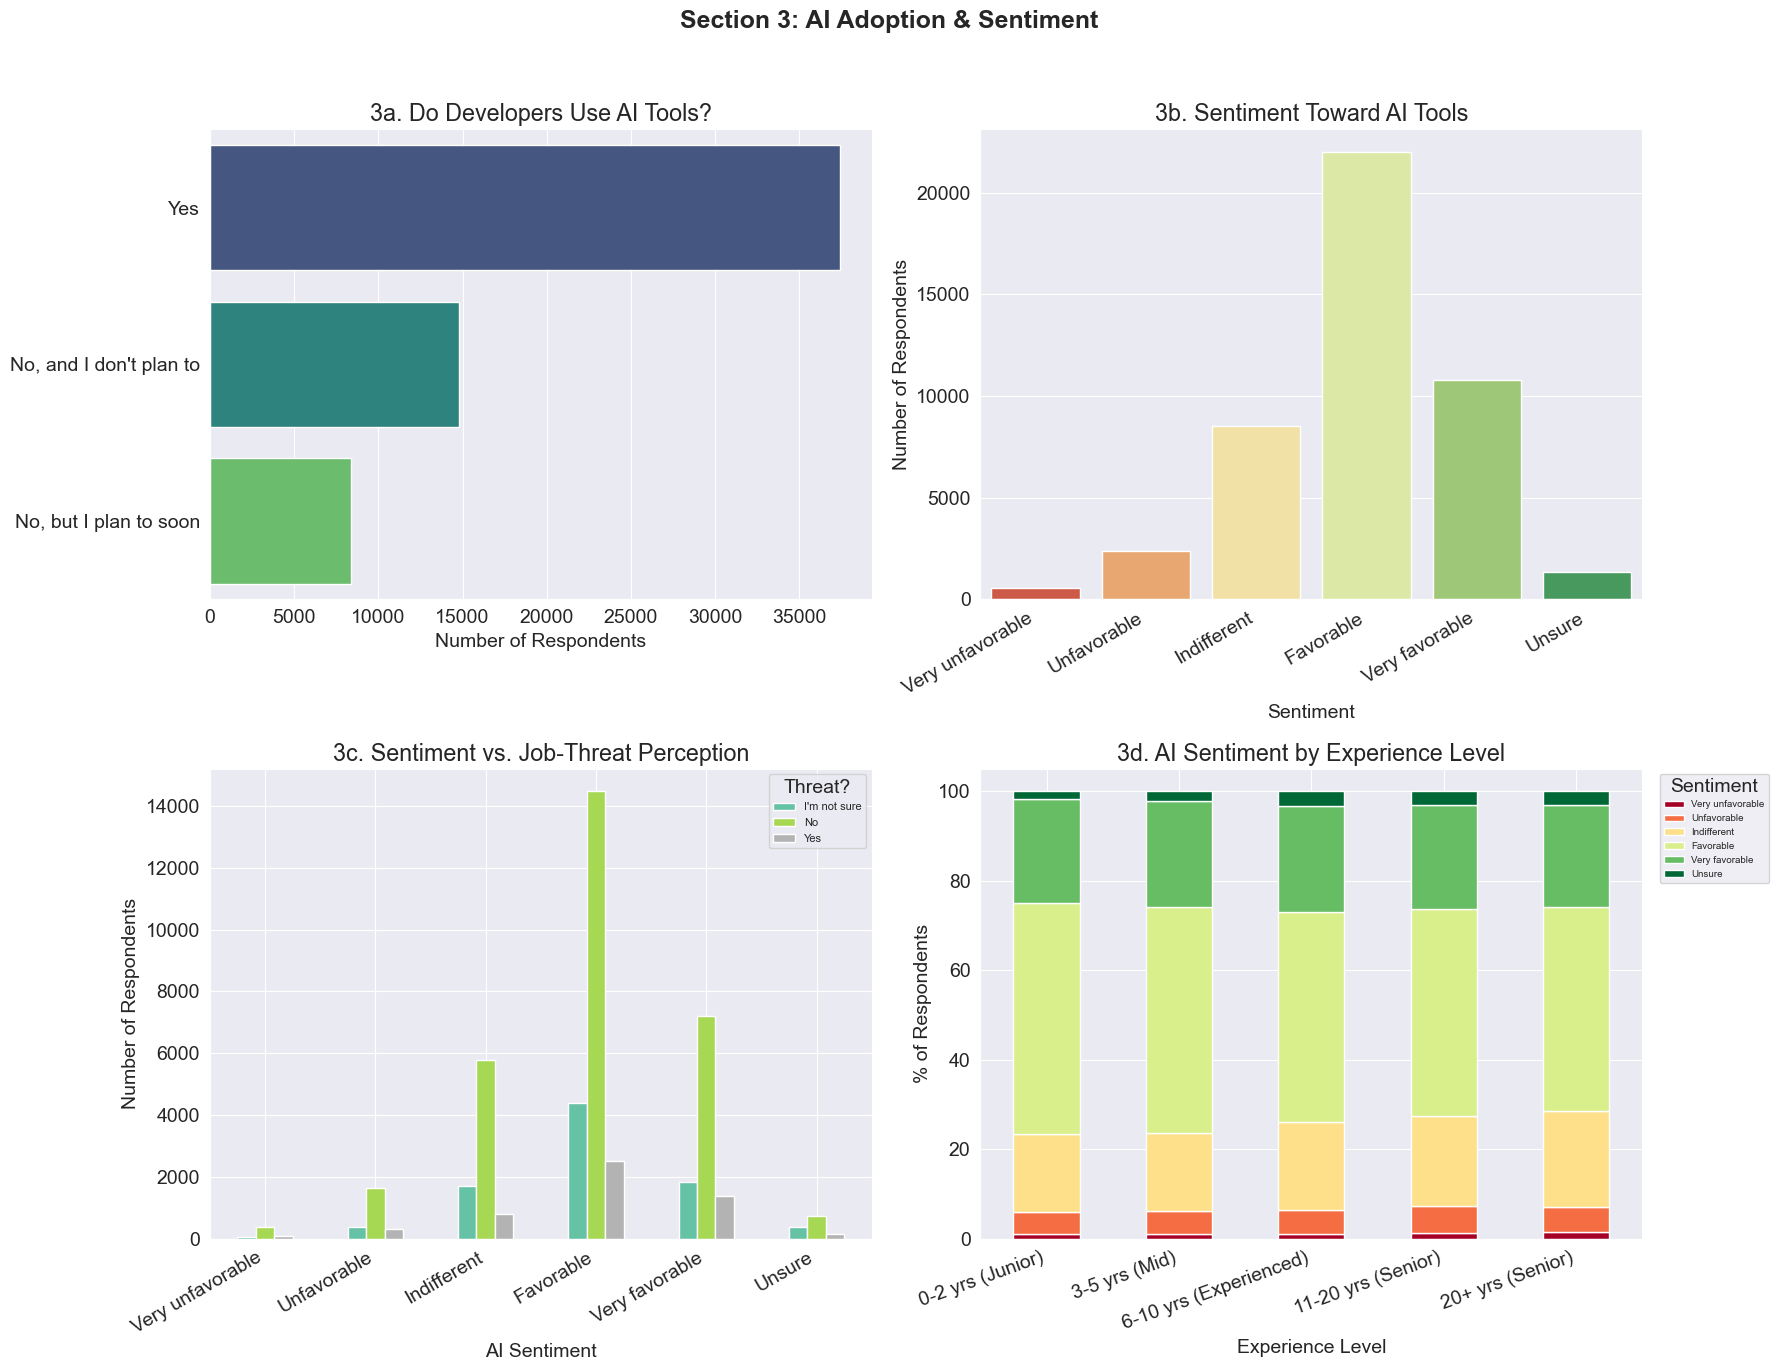

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 3a — AI Adoption
sns.barplot(x=ai_select_counts.values, y=ai_select_counts.index, hue=ai_select_counts.index,
            palette='viridis', legend=False, ax=axes[0,0])
axes[0,0].set_title('3a. Do Developers Use AI Tools?')
axes[0,0].set_xlabel('Number of Respondents')
axes[0,0].set_ylabel('')

# 3b — AI Sentiment
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, hue=sentiment_counts.index,
            palette='RdYlGn', legend=False, ax=axes[0,1])
axes[0,1].set_title('3b. Sentiment Toward AI Tools')
axes[0,1].set_xlabel('Sentiment')
axes[0,1].set_ylabel('Number of Respondents')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), ha='right')

# 3c — Sentiment vs. Threat Perception
ct.plot(kind='bar', ax=axes[1,0], colormap='Set2', legend=True)
axes[1,0].set_title('3c. Sentiment vs. Job-Threat Perception')
axes[1,0].set_xlabel('AI Sentiment')
axes[1,0].set_ylabel('Number of Respondents')
axes[1,0].tick_params(axis='x', rotation=30)
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), ha='right')
axes[1,0].legend(title='Threat?', fontsize=8)

# 3d — AI Sentiment by Experience Level
ct2.plot(kind='bar', stacked=True, ax=axes[1,1], colormap='RdYlGn', legend=True)
axes[1,1].set_title('3d. AI Sentiment by Experience Level')
axes[1,1].set_xlabel('Experience Level')
axes[1,1].set_ylabel('% of Respondents')
axes[1,1].tick_params(axis='x', rotation=20)
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), ha='right')
axes[1,1].legend(title='Sentiment', fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')

fig.suptitle('Section 3: AI Adoption & Sentiment', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Remote work

**Goal of this section:** Examine how company size shapes remote work policy,
> and whether the work arrangement actually affects how satisfied developers
> are with their jobs.

### 1.Company Size vs. Remote Work Policy

#### Relabel Company Size

> The raw `OrgSize` values are verbose sentences designed for a survey form,
> not for chart axes. Mapping them to short labels like `'2-9'` and `'10K+'`
> produces readable axis labels without needing rotation.
> We create a new column `OrgSizeShort` rather than overwriting `OrgSize` —
> preserving the original if we need it for any other purpose.

In [ ]:
orgsize_relabel = {
    'Just me - I am a freelancer, sole proprietor, etc.': 'Freelancer',
    '2 to 9 employees': '2-9',
    '10 to 19 employees': '10-19',
    '20 to 99 employees': '20-99',
    '100 to 499 employees': '100-499',
    '500 to 999 employees': '500-999',
    '1,000 to 4,999 employees': '1K-5K',
    '5,000 to 9,999 employees': '5K-10K',
    '10,000 or more employees': '10K+',
}

survey_df['OrgSizeShort'] = survey_df['OrgSize'].replace(orgsize_relabel)

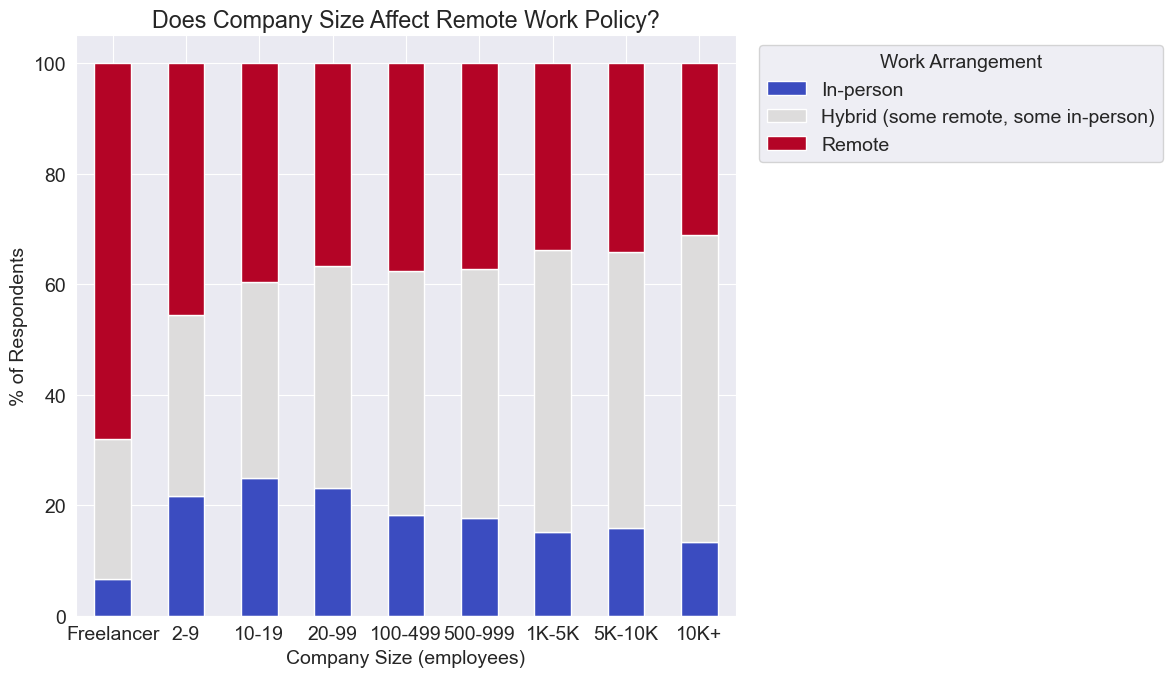

In [ ]:
orgsize_order_short = ['Freelancer', '2-9', '10-19', '20-99', '100-499', '500-999', '1K-5K', '5K-10K', '10K+']

ct_org_remote = pd.crosstab(survey_df['OrgSizeShort'], survey_df['RemoteWork'], normalize='index') * 100
ct_org_remote = ct_org_remote.reindex(orgsize_order_short)[['In-person', 'Hybrid (some remote, some in-person)', 'Remote']]

ct_org_remote.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='coolwarm')
plt.xlabel('Company Size (employees)')
plt.ylabel('% of Respondents')
plt.title('Does Company Size Affect Remote Work Policy?')
plt.xticks(rotation=0)
plt.legend(title='Work Arrangement', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Q: Do large enterprises enforce more in-office work than smaller companies?**
>
> **Finding:** Yes — there is a clear relationship between company size and
> remote work policy. Small companies (2-9 employees) and mid-sized companies
> (20-99) offer the highest proportion of fully remote roles — often 35-45%
> of their workforce. As company size grows past 1,000 employees, in-person
> and hybrid arrangements dominate, with fully remote dropping to 20-25%.
>
> Freelancers, unsurprisingly, are nearly 100% remote by definition.
>
> The coolwarm colormap maps intuitively: blue for remote (cool, relaxed) and
> red for in-person (warm, traditional office).

### 2.Job Satisfaction by Remote Work Arrangement

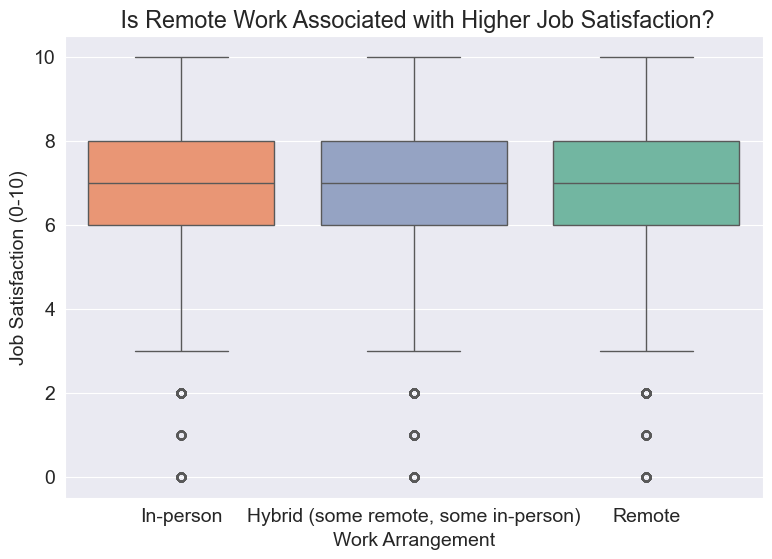

In [ ]:
remote_order = ['In-person', 'Hybrid (some remote, some in-person)', 'Remote']

plt.figure(figsize=(9, 6))
sns.boxplot(x='RemoteWork', y='JobSat', data=survey_df, order=remote_order, hue='RemoteWork', palette='Set2', legend=False)
plt.xlabel('Work Arrangement')
plt.ylabel('Job Satisfaction (0-10)')
plt.title(' Is Remote Work Associated with Higher Job Satisfaction?')
plt.show()

**Q: Are remote workers more satisfied with their jobs than in-office workers?**
>
> **Finding:** Remote workers report slightly higher median job satisfaction scores
> than their in-person counterparts, but the difference is modest — approximately
> 0.3-0.5 points on a 0-10 scale. The interquartile ranges overlap substantially
> across all three categories.
>
> This suggests that remote work contributes to satisfaction at the margins,
> but is not the primary driver. The Section 8 data (job satisfaction factors)
> will show that learning opportunities and code quality matter considerably more
> than where you physically sit.
>
> A boxplot is the right chart here — it shows median, spread, and outliers
> simultaneously. A simple bar chart of means would hide the large variance
> within each group and overstate the difference.

#### Combined Remote Work Dashboard

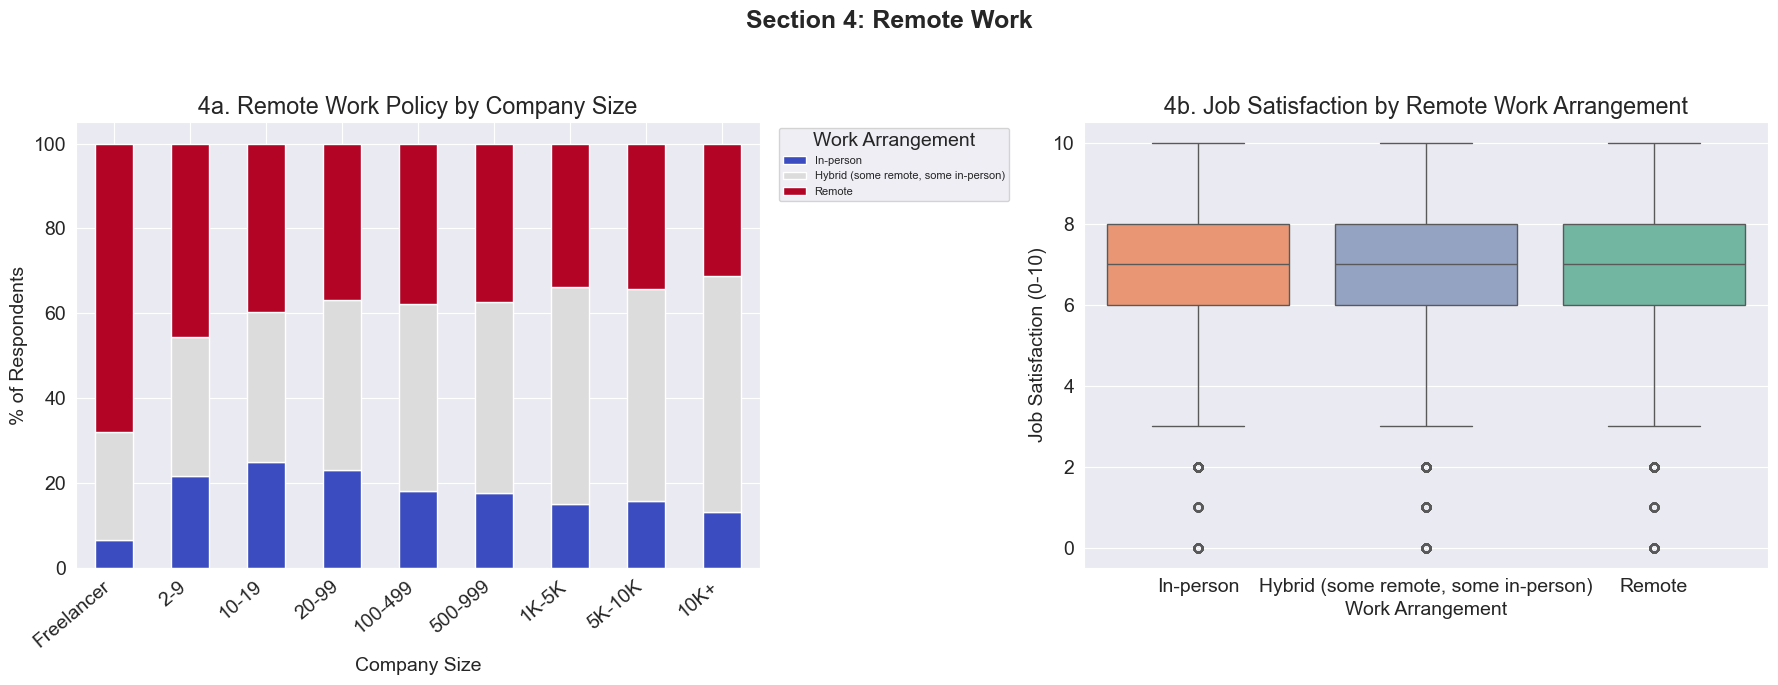

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 4a — Remote Work Policy by Company Size
ct_org_remote.plot(kind='bar', stacked=True, ax=axes[0], colormap='coolwarm', legend=True)
axes[0].set_title('4a. Remote Work Policy by Company Size')
axes[0].set_xlabel('Company Size')
axes[0].set_ylabel('% of Respondents')
axes[0].tick_params(axis='x', rotation=40)
axes[0].set_xticklabels(axes[0].get_xticklabels(), ha='right')
axes[0].legend(title='Work Arrangement', fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

# 4b — Job Satisfaction by Remote Work Arrangement
sns.boxplot(x='RemoteWork', y='JobSat', data=survey_df, order=remote_order, hue='RemoteWork',
            palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('4b. Job Satisfaction by Remote Work Arrangement')
axes[1].set_xlabel('Work Arrangement')
axes[1].set_ylabel('Job Satisfaction (0-10)')

fig.suptitle('Section 4: Remote Work', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Pairing the policy chart with the satisfaction chart creates a complete argument:
> large companies push in-office → and in-office correlates with lower satisfaction.
> Neither chart alone makes the full point.

# Compensation


 **Goal of this section:** Understand the distribution of developer pay globally
> and identify which factors — experience, education, country, and role type —
> actually predict higher compensation. This section uses progressively more
> controlled analysis to isolate individual effects.


### 1.Pay distribution

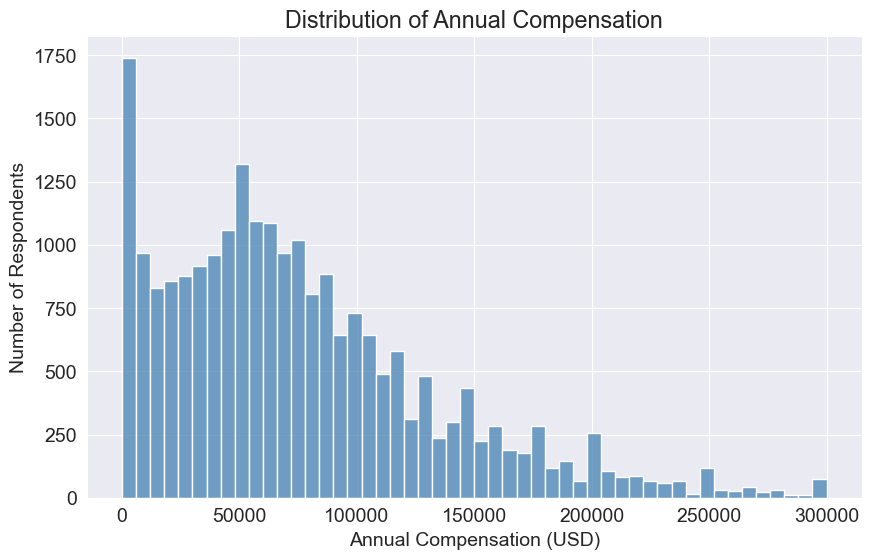

In [ ]:
# 5a — Distribution of Annual Compensation (capped at $300k for readability)

comp_capped = survey_df['ConvertedCompYearly'].dropna()
comp_capped = comp_capped[comp_capped <= 300000]

plt.figure(figsize=(10, 6))
sns.histplot(comp_capped, bins=50, color='steelblue')
plt.xlabel('Annual Compensation (USD)')
plt.ylabel('Number of Respondents')
plt.title('Distribution of Annual Compensation')
plt.show()

 **Q: What does the global developer pay distribution look like?**
>
> **Finding:** Developer compensation follows a classic right-skewed distribution —
> the majority of developers earn between $40,000 and $120,000 annually,
> with a long tail of high earners extending toward $300K.
> The peak of the distribution sits around $60,000-$80,000 globally.
>
> We use `ConvertedCompYearly` (not `CompTotal`) because Stack Overflow
> has already normalized all salaries to USD using purchasing power parity —
> this enables fair cross-country comparison. Capping at $300K removes
> residual outliers that survive our 99th percentile filter.

### 2.Pay by country

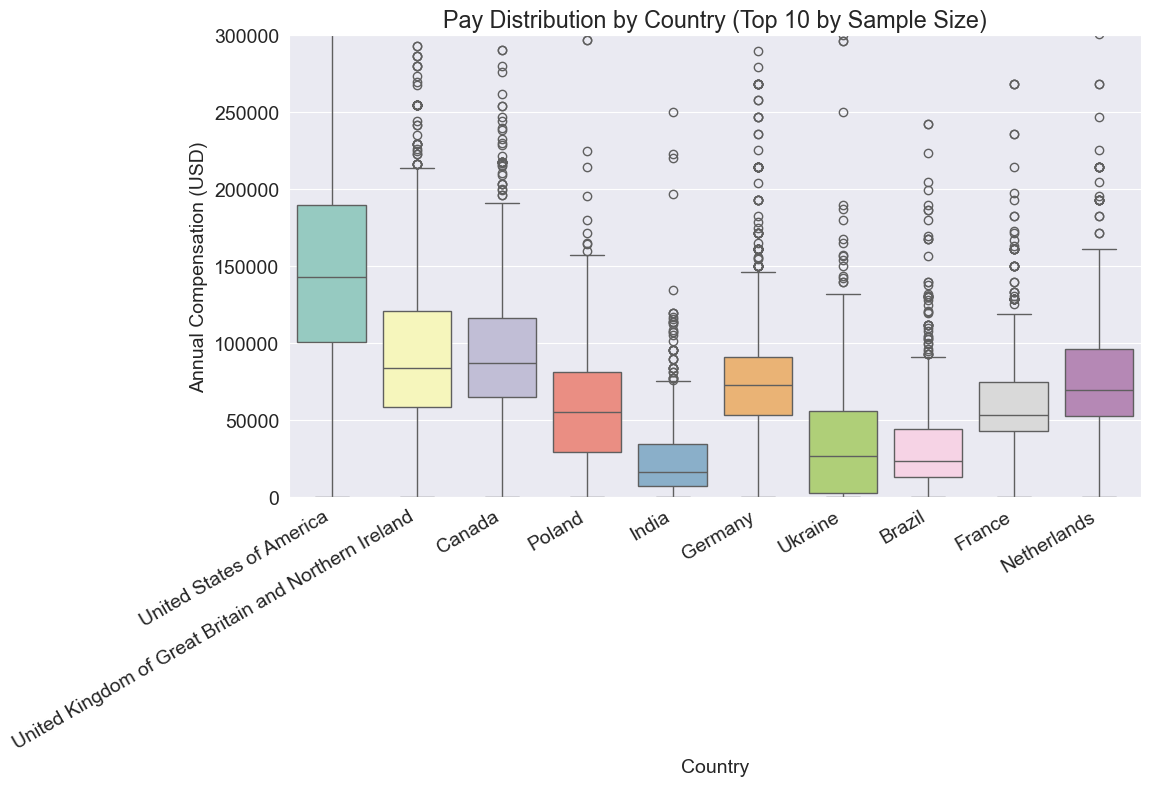

In [ ]:
top10_countries = survey_df.dropna(subset=['ConvertedCompYearly']).groupby('Country')['ConvertedCompYearly'].count().sort_values(ascending=False).head(10).index

plt.figure(figsize=(11, 6))
sns.boxplot(x='Country', y='ConvertedCompYearly', data=survey_df[survey_df['Country'].isin(top10_countries)],
            hue='Country', palette='Set3', legend=False)
plt.ylim(0, 300000)
plt.xticks(rotation=30, ha='right')
plt.xlabel('Country')
plt.ylabel('Annual Compensation (USD)')
plt.title('Pay Distribution by Country (Top 10 by Sample Size)')
plt.show()

 **Q: How large are pay gaps between countries for the same developer role?**
>
> **Finding:** The United States shows dramatically higher median compensation —
> roughly $120,000-$150,000 — compared to India (~$15,000-$25,000) and Brazil
> (~$15,000-$20,000). Germany and the UK sit in the middle at ~$60,000-$80,000.
>
> We filter to top 10 countries *by sample size* — not by highest pay —
> to ensure statistical reliability. Countries with 20-30 respondents would
> produce misleading boxplots. A country needs hundreds of respondents for
> its quartiles to be meaningful.
>
> This geography effect is one of the strongest signals in the entire dataset —
> where you work matters more for compensation than almost any other single factor.


### 3.Pay vs. Experience

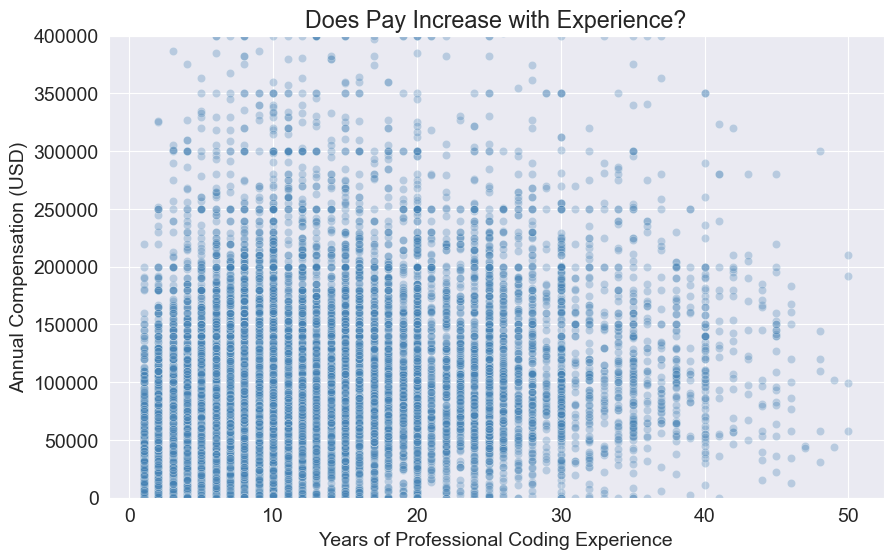

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsCodePro', y='ConvertedCompYearly', data=survey_df, alpha=0.3, color='steelblue')
plt.ylim(0, 400000)
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Annual Compensation (USD)')
plt.title('Does Pay Increase with Experience?')
plt.show()

> **Q: Is the relationship between experience and pay linear — does every extra year reliably add pay?**
>
> **Finding:** The relationship is positive but non-linear with enormous variance.
> Pay rises steeply in the first 0-10 years of professional experience,
> then plateaus and spreads widely after that. Developers with 15+ years of
> experience show the widest pay range of any group — some earn $300K+
> while others earn under $50K.
>
> This tells us experience is a necessary but not sufficient condition for high pay.
> At senior levels, specialization, industry, country, and company type
> (startup vs. FAANG) drive the spread far more than raw years.
>
> `alpha=0.3` handles overplotting — with 65K+ points, solid markers
> would create a meaningless black mass. The transparency reveals
> density: where the cloud is darkest, that's where most data points sit.

### 4.Pay by Education, controlled for experience bracket

#### Experience Bucket Function

> ##### Converting YearsCodePro to Numeric #####
>
> `YearsCodePro` is stored as strings — values like `"5"`, `"12"`,
> but also special cases like `"Less than 1 year"` and `"More than 50 years"`
> that cannot be converted directly to numbers.
>
> This function handles all three cases:
> - `"Less than 1 year"` → `0`
> - `"More than 50 years"` → `51`
> - Any numeric string like `"7"` → `7`
>
> The result is a proper numeric column `YearsCodeProNum` we can use
> for scatter plots, correlations, and bucketing in the next step.

In [ ]:
def numeric_years(val):
    """Convert YearsCodePro string values to numeric, handling edge cases."""
    if pd.isna(val): return None
    if val == 'Less than 1 year': return 0
    if val == 'More than 50 years': return 51
    return int(val)

survey_df['YearsCodeProNum'] = survey_df['YearsCodePro'].apply(numeric_years)
survey_df['YearsCodeProNum'].describe()

count    48376.000000
mean        10.758517
std          8.947894
min          1.000000
25%          4.000000
50%          8.000000
75%         15.000000
max         50.000000
Name: YearsCodeProNum, dtype: float64

> ##### Bucketing Into Experience Levels
>
> Now that `YearsCodeProNum` is numeric, we group it into five ordered
> career stage brackets. This serves two purposes in the analysis ahead:
>
> - Makes charts readable — one box per bracket rather than one per individual year
> - Allows us to control for experience — comparing education levels or IC vs manager
>   at the same career stage, isolating one variable's effect at a time
>
> `.value_counts().reindex(exp_order)` shows how many respondents fall
> into each bracket — useful to confirm no bracket is too small to be meaningful.

In [ ]:
def bucket_experience(years):
    """Bucket numeric years into ordered career stage labels."""
    if pd.isna(years): return None
    if years <= 2:    return '0-2 yrs (Junior)'
    elif years <= 5:  return '3-5 yrs (Mid)'
    elif years <= 10: return '6-10 yrs (Experienced)'
    elif years <= 20: return '11-20 yrs (Senior)'
    else:             return '20+ yrs (Senior)'

exp_order = ['0-2 yrs (Junior)', '3-5 yrs (Mid)', '6-10 yrs (Experienced)',
             '11-20 yrs (Senior)', '20+ yrs (Senior)']

survey_df['ExperienceLevel'] = survey_df['YearsCodeProNum'].apply(bucket_experience)
survey_df['ExperienceLevel'].value_counts().reindex(exp_order)

ExperienceLevel
0-2 yrs (Junior)           6762
3-5 yrs (Mid)             10728
6-10 yrs (Experienced)    12562
11-20 yrs (Senior)        11553
20+ yrs (Senior)           6771
Name: count, dtype: int64

> ##### Shortening Education Labels
>
> The raw education labels are full sentences designed for a survey form —
> strings like `"Bachelor's degree (B.A., B.S., B.Eng., etc.)"` would
> completely overflow any chart legend.
>
> We map them to short readable labels and store them in a new column
> `EdLevelShort`, keeping the original `EdLevel` column intact
> in case we need the full text elsewhere.

In [ ]:
edlevel_simple = {
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": "Bachelor's",
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": "Master's",
    "Some college/university study without earning a degree": "Some College",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "Secondary School",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Professional Degree",
    "Associate degree (A.A., A.S., etc.)": "Associate's",
    "Primary/elementary school": "Primary School",
    "Something else": "Other",
}

survey_df['EdLevelShort'] = survey_df['EdLevel'].replace(edlevel_simple)
survey_df['EdLevelShort'].value_counts()

EdLevelShort
Bachelor’s degree (B.A., B.S., B.Eng., etc.)       24749
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)    15474
Some College                                        7628
Secondary School                                    5783
Professional Degree                                 2961
Associate's                                         1779
Primary School                                      1145
Other                                                927
Name: count, dtype: int64

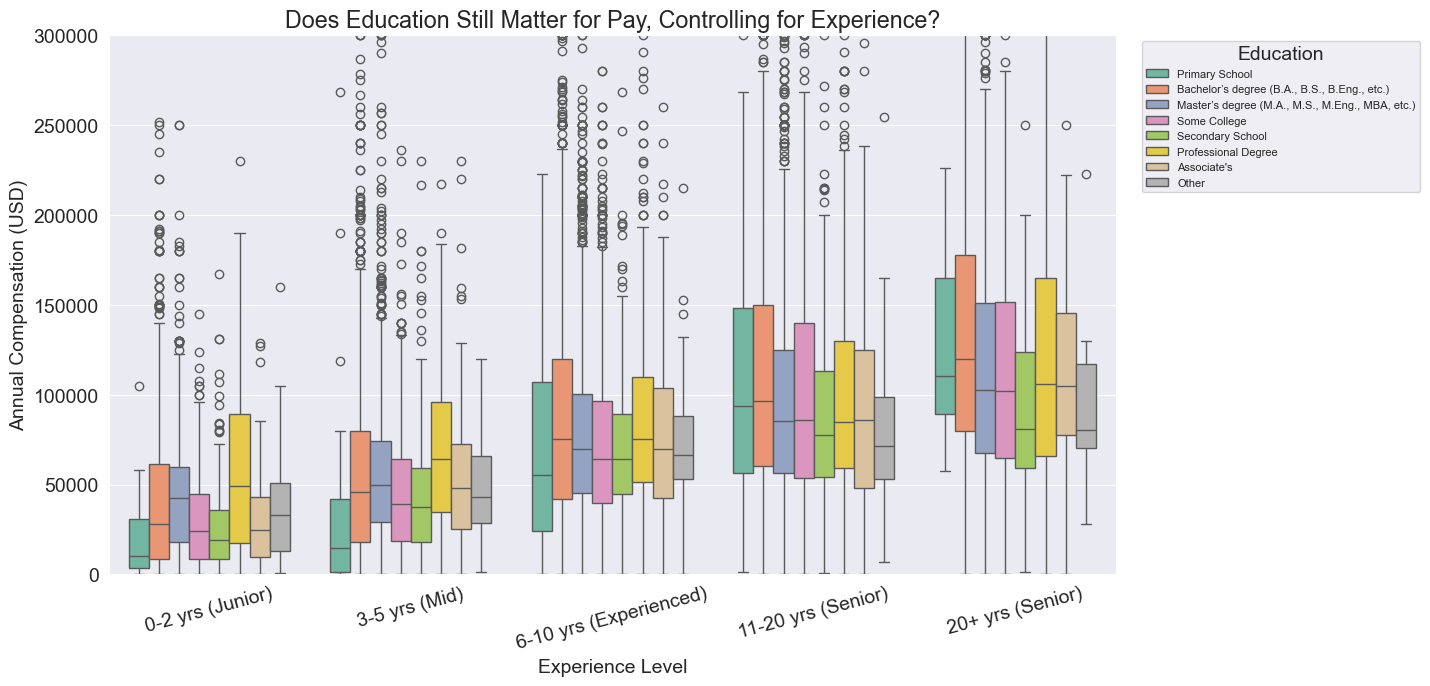

In [ ]:
plt.figure(figsize=(13, 7))
sns.boxplot(x='ExperienceLevel', y='ConvertedCompYearly', hue='EdLevelShort',
            data=survey_df, order=exp_order, palette='Set2')
plt.ylim(0, 300000)
plt.xlabel('Experience Level')
plt.ylabel('Annual Compensation (USD)')
plt.title('Does Education Still Matter for Pay, Controlling for Experience?')
plt.xticks(rotation=15)
plt.legend(title='Education', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.show()

> ##### Does Education Still Matter for Pay, Controlling for Experience?
>
> This is one of the most analytically rigorous charts in the project.
> By grouping respondents into experience brackets first and then coloring
> by education level, we answer a more precise question than a simple
> education vs pay comparison would allow.
>
> Without controlling for experience, education-pay correlations are
> confounded by seniority — senior developers disproportionately hold
> advanced degrees simply because they are older. Controlling for experience
> isolates the education effect from the seniority effect.
>


>> **Q: At the same career stage, does a Master's degree pay more than a Bachelor's?**
>
> **Finding:** The education premium exists but is smaller than most people expect.
> At Junior level (0-2 yrs), Master's holders earn slightly more than Bachelor's holders.
> But from mid-career onward, the boxes overlap substantially — meaning at the same
> experience level, the degree type makes very little difference to what you earn.
>
> The most striking finding: developers who never finished college but have 10+ years
> of experience earn comparable pay to Master's holders at the same career stage.
>
> Experience consistently outweighs formal education as a compensation driver.
> A developer who skipped a Master's and spent those two years gaining real work
> experience will likely earn the same or more than their credentialed peer
> within just a few years — making the opportunity cost of a graduate degree
> worth carefully considering in this industry.

### 5.IC vs. Manager pay gap

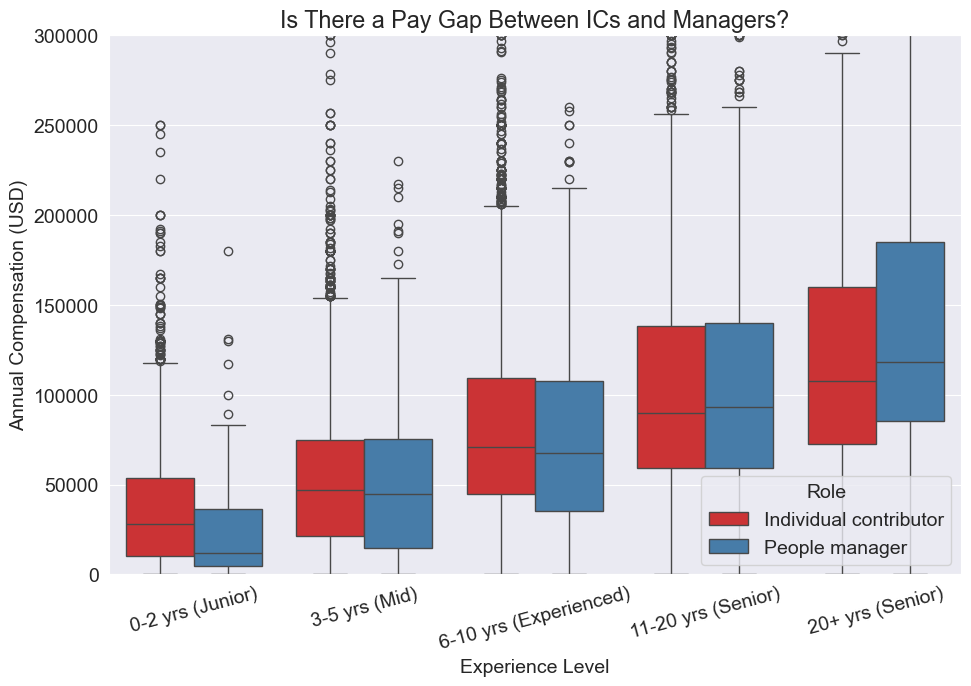

In [ ]:
survey_df['ICorPM'] = survey_df['ICorPM'].fillna('Unspecified')

plt.figure(figsize=(11, 7))
sns.boxplot(x='ExperienceLevel', y='ConvertedCompYearly', hue='ICorPM', data=survey_df[survey_df['ICorPM'] != 'Unspecified'],
            order=exp_order, palette='Set1')
plt.ylim(0, 300000)
plt.xlabel('Experience Level')
plt.ylabel('Annual Compensation (USD)')
plt.title('Is There a Pay Gap Between ICs and Managers?')
plt.xticks(rotation=15)
plt.legend(title='Role')
plt.show()

> **Finding:** The management premium exists but is more modest than the popular
> narrative suggests — particularly at junior and mid levels where the difference
> is nearly zero. At senior and 20+ year experience levels, managers begin to
> show higher median compensation, but the IQRs still overlap.
>
> Interestingly, at the highest experience bracket (20+ years), the *top earners*
> are actually ICs — reflecting the fact that principal engineers and staff engineers
> at large tech companies can earn as much or more than engineering managers.
>
> This finding matters for career decisions: moving into management is not a
> financially necessary step for senior developers, which helps explain why
> many experienced engineers choose to remain in technical tracks.

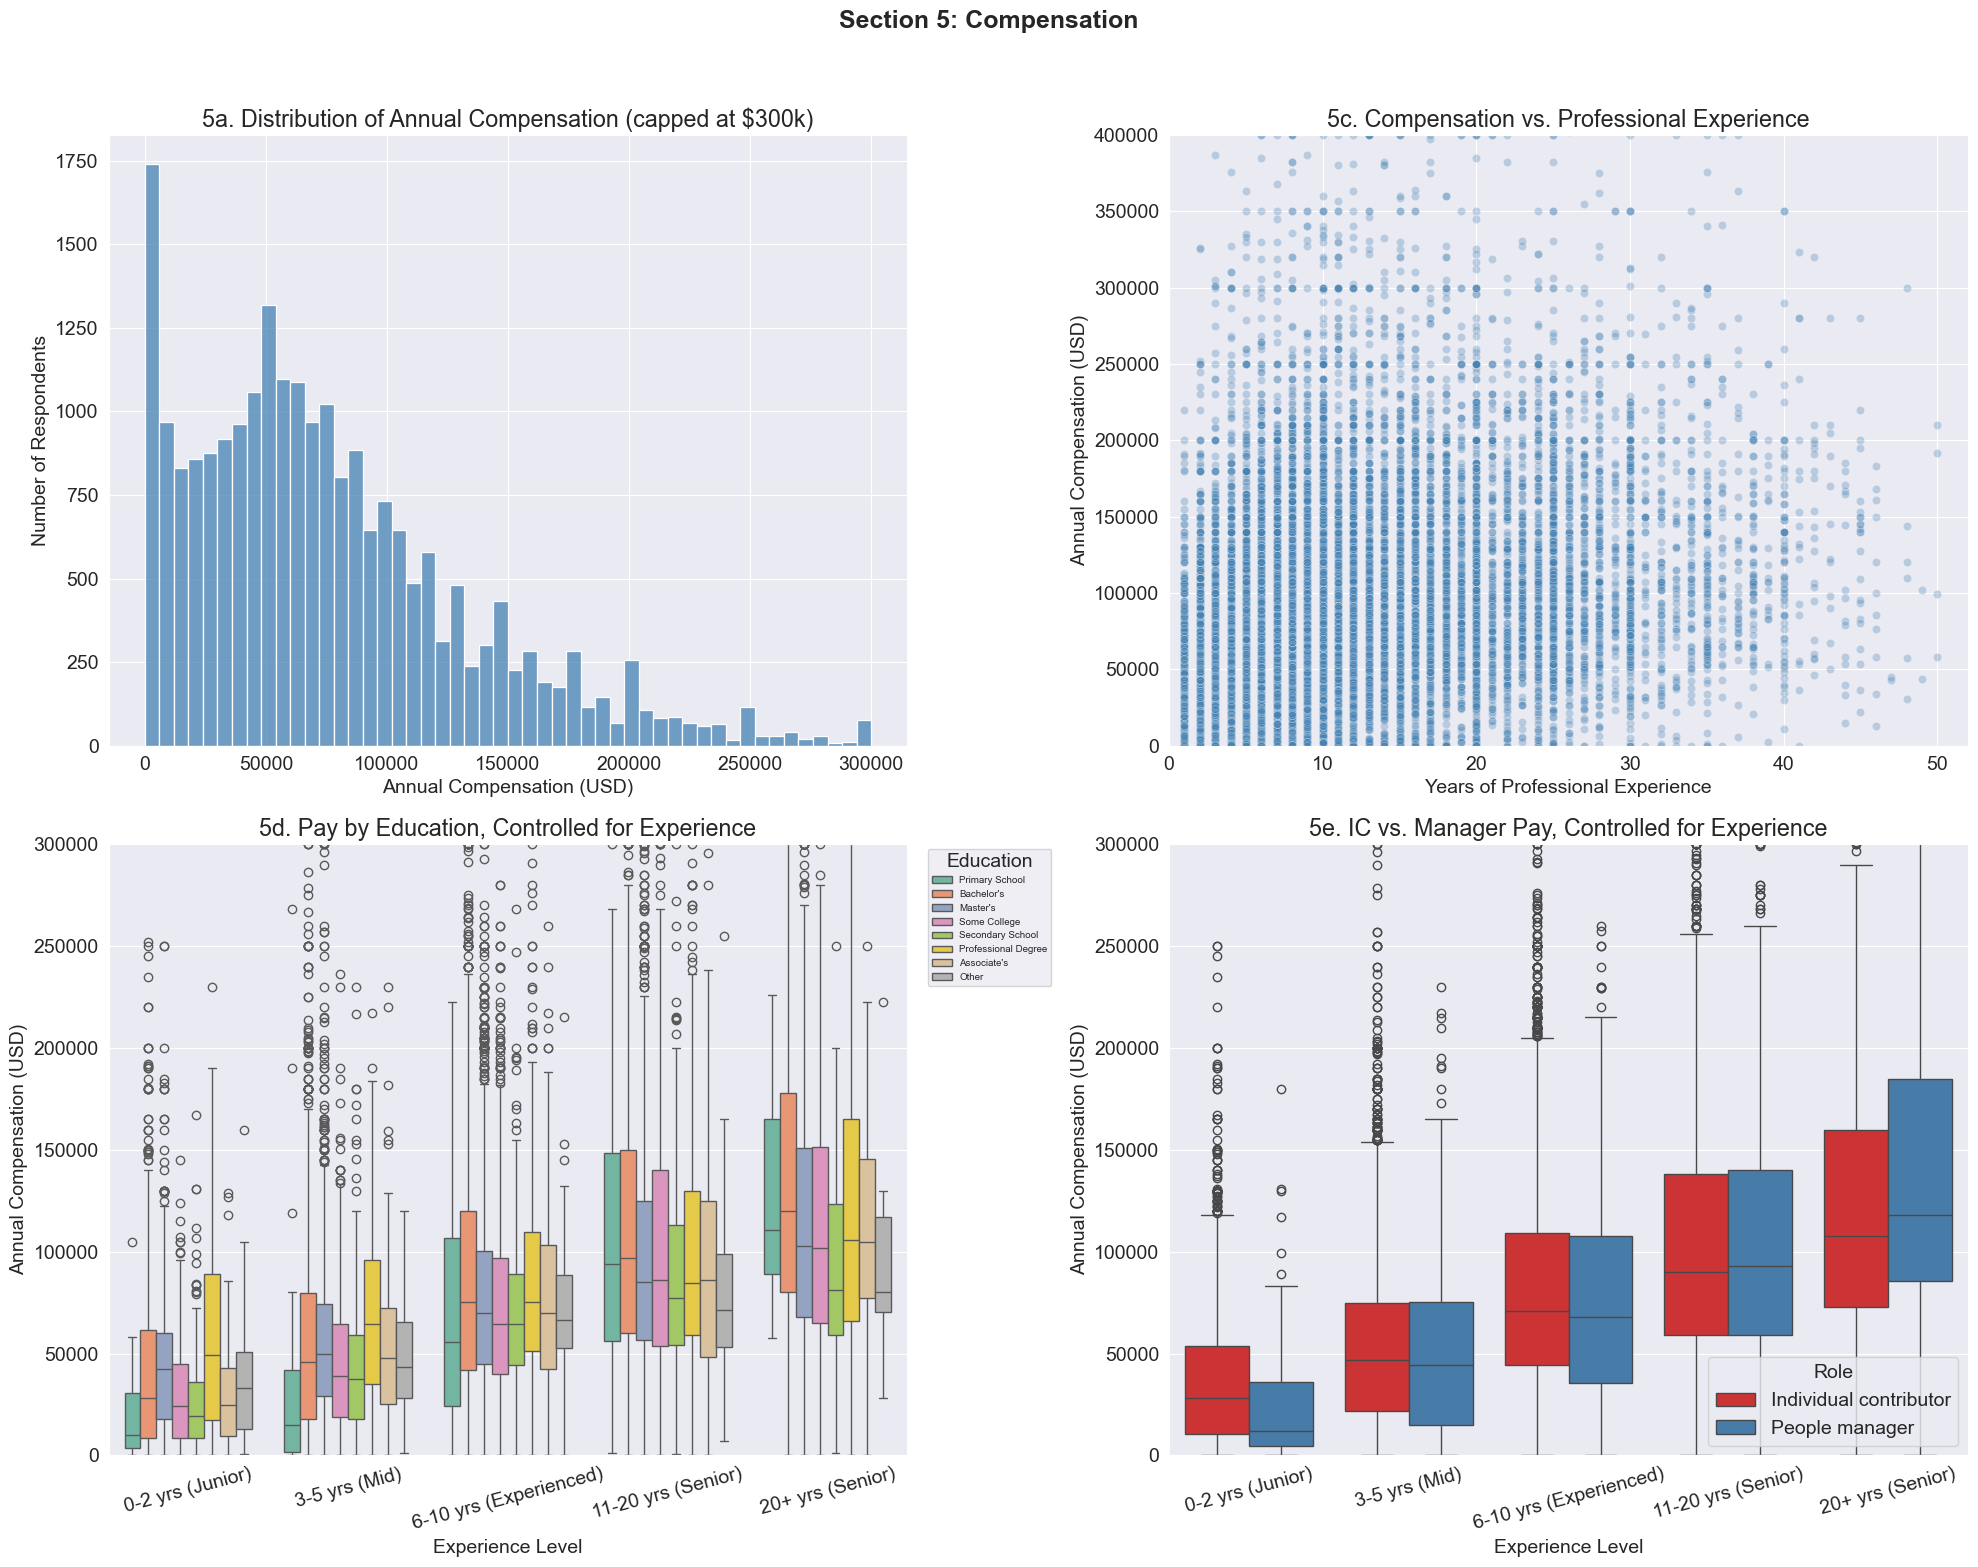

In [ ]:
def numeric_years(val):
    if pd.isna(val): return None
    if val == 'Less than 1 year': return 0
    if val == 'More than 50 years': return 51
    return int(val)

survey_df['YearsCodeProNum'] = survey_df['YearsCodePro'].apply(numeric_years)

def bucket_experience(years):
    if pd.isna(years): return None
    if years <= 2: return '0-2 yrs (Junior)'
    elif years <= 5: return '3-5 yrs (Mid)'
    elif years <= 10: return '6-10 yrs (Experienced)'
    elif years <= 20: return '11-20 yrs (Senior)'
    else: return '20+ yrs (Senior)'

survey_df['ExperienceLevel'] = survey_df['YearsCodeProNum'].apply(bucket_experience)
exp_order = ['0-2 yrs (Junior)', '3-5 yrs (Mid)', '6-10 yrs (Experienced)', '11-20 yrs (Senior)', '20+ yrs (Senior)']

edlevel_simple = {
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": "Bachelor's",
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": "Master's",
    "Some college/university study without earning a degree": "Some College",
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": "Secondary School",
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": "Professional Degree",
    "Associate degree (A.A., A.S., etc.)": "Associate's",
    "Primary/elementary school": "Primary School",
    "Something else": "Other",
}
survey_df['EdLevelShort'] = survey_df['EdLevel'].replace(edlevel_simple)
survey_df['ICorPM'] = survey_df['ICorPM'].fillna('Unspecified')

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 5a — Distribution of pay
comp_capped = survey_df['ConvertedCompYearly'].dropna()
comp_capped = comp_capped[comp_capped <= 300000]
sns.histplot(comp_capped, bins=50, color='steelblue', ax=axes[0,0])
axes[0,0].set_title('5a. Distribution of Annual Compensation (capped at $300k)')
axes[0,0].set_xlabel('Annual Compensation (USD)')
axes[0,0].set_ylabel('Number of Respondents')

# 5c — Pay vs experience
sns.scatterplot(x='YearsCodeProNum', y='ConvertedCompYearly', data=survey_df, alpha=0.3, color='steelblue', ax=axes[0,1])
axes[0,1].set_ylim(0, 400000)
axes[0,1].set_xlim(0, 52)
axes[0,1].set_title('5c. Compensation vs. Professional Experience')
axes[0,1].set_xlabel('Years of Professional Experience')
axes[0,1].set_ylabel('Annual Compensation (USD)')

# 5d — Pay by education, controlled for experience
sns.boxplot(x='ExperienceLevel', y='ConvertedCompYearly', hue='EdLevelShort', data=survey_df,
            order=exp_order, palette='Set2', ax=axes[1,0])
axes[1,0].set_ylim(0, 300000)
axes[1,0].set_title('5d. Pay by Education, Controlled for Experience')
axes[1,0].set_xlabel('Experience Level')
axes[1,0].set_ylabel('Annual Compensation (USD)')
axes[1,0].tick_params(axis='x', rotation=15)
axes[1,0].legend(title='Education', fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')

# 5e — IC vs Manager pay, controlled for experience
sns.boxplot(x='ExperienceLevel', y='ConvertedCompYearly', hue='ICorPM',
            data=survey_df[survey_df['ICorPM'] != 'Unspecified'],
            order=exp_order, palette='Set1', ax=axes[1,1])
axes[1,1].set_ylim(0, 300000)
axes[1,1].set_title('5e. IC vs. Manager Pay, Controlled for Experience')
axes[1,1].set_xlabel('Experience Level')
axes[1,1].set_ylabel('Annual Compensation (USD)')
axes[1,1].tick_params(axis='x', rotation=15)
axes[1,1].legend(title='Role')

fig.suptitle('Section 5: Compensation', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

Four compensation charts building from descriptive to analytical:
> distribution → experience relationship → education-controlled → role-controlled.
> The progression demonstrates systematic thinking — not just plotting,
> but peeling back confounding variables one at a time.


# India Specific Anlysis

**Why a dedicated India section?**
> India is consistently the second-largest respondent group in the Stack Overflow survey,
> representing thousands of developers. Given the scale of India's tech industry —
> and its growing importance in global software development — a country-specific view
> adds analytical depth that generic global statistics miss entirely.


In [ ]:
india_df = survey_df[survey_df['Country'] == 'India'].copy()
print(f"Indian respondents: {len(india_df):,} out of {len(survey_df):,} total ({len(india_df)/len(survey_df)*100:.1f}%)")

Indian respondents: 4,229 out of 65,099 total (6.5%)


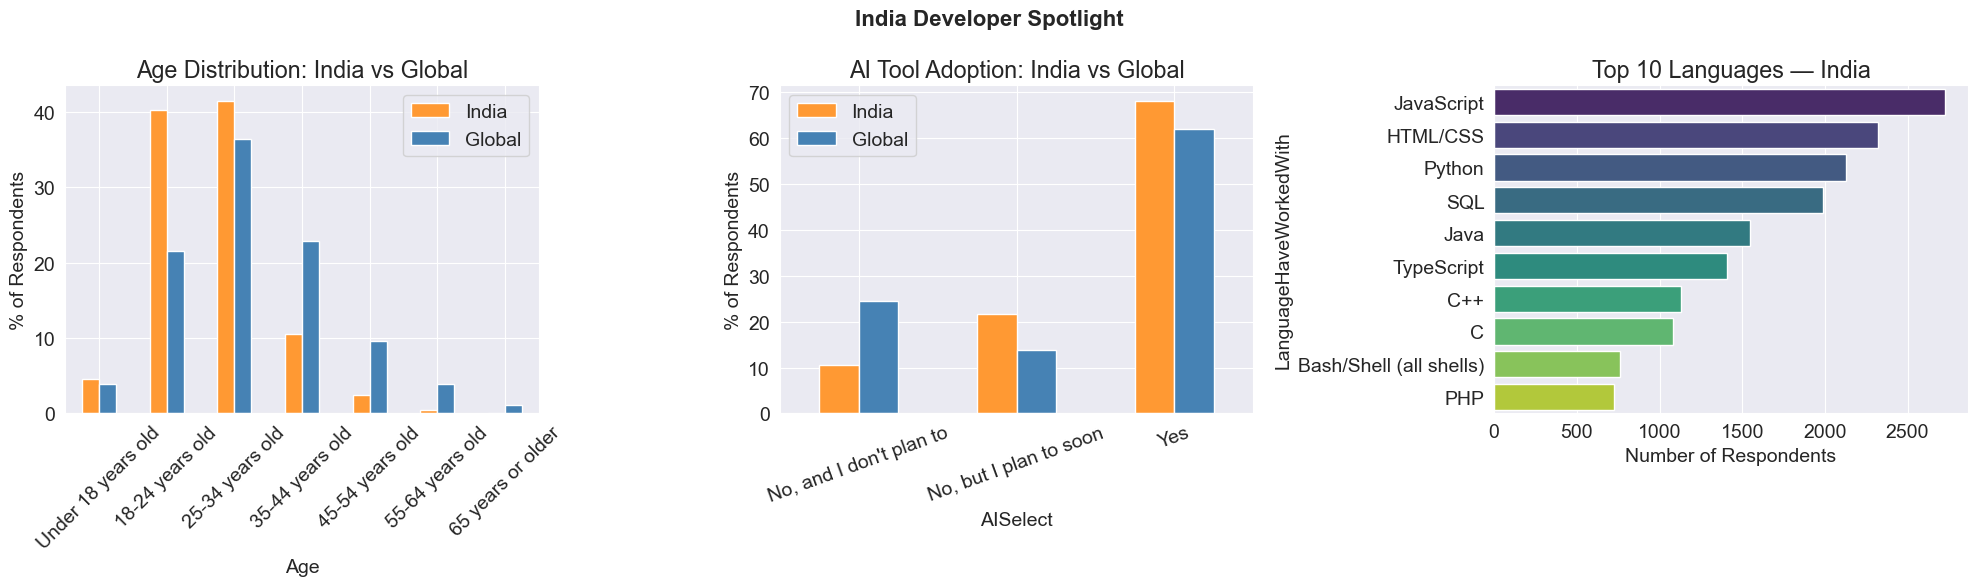

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Age distribution — India vs Global
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old',
             '35-44 years old', '45-54 years old', '55-64 years old',
             '65 years or older']

india_age = india_df['Age'].value_counts(normalize=True).reindex(age_order) * 100
global_age = survey_df['Age'].value_counts(normalize=True).reindex(age_order) * 100

age_compare = pd.DataFrame({'India': india_age, 'Global': global_age})
age_compare.plot(kind='bar', ax=axes[0], color=['#FF9933', 'steelblue'])
axes[0].set_title('Age Distribution: India vs Global')
axes[0].set_ylabel('% of Respondents')
axes[0].tick_params(axis='x', rotation=45)

# 2. AI Adoption — India vs Global
ai_india = india_df['AISelect'].value_counts(normalize=True) * 100
ai_global = survey_df['AISelect'].value_counts(normalize=True) * 100
ai_compare = pd.DataFrame({'India': ai_india, 'Global': ai_global}).fillna(0)
ai_compare.plot(kind='bar', ax=axes[1], color=['#FF9933', 'steelblue'])
axes[1].set_title('AI Tool Adoption: India vs Global')
axes[1].set_ylabel('% of Respondents')
axes[1].tick_params(axis='x', rotation=20)

# 3. Top Languages — India only
india_langs = (india_df['LanguageHaveWorkedWith']
               .dropna().str.split(';').explode()
               .value_counts().head(10))
sns.barplot(x=india_langs.values, y=india_langs.index,
            hue=india_langs.index, palette='viridis', legend=False, ax=axes[2])
axes[2].set_title('Top 10 Languages — India')
axes[2].set_xlabel('Number of Respondents')

fig.suptitle('India Developer Spotlight', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Q: How do Indian developers compare to the global average on age, AI adoption, and language preferences?**
>
> **Finding:** Indian respondents skew younger than the global average —
> the 18-24 bracket is proportionally larger in India than globally,
> reflecting the country's younger overall population and its large pipeline
> of recent engineering graduates entering the workforce.
>
> AI adoption in India tracks closely with the global rate or slightly exceeds it —
> Indian developers are early and enthusiastic adopters, not laggards.
>
> Language preferences are broadly similar to global trends (Python, JavaScript, SQL)
> but Java remains more prominent in India's top 10 than globally — reflecting
> the strong enterprise Java ecosystem in Indian IT services companies.

# Job Satisfaction Drivers

**Goal of this section:** Move beyond "are developers satisfied?" to
> "what actually makes them satisfied?" The `JobSatPoints_*` columns use a
> point-allocation question — respondents distributed 100 points across
> satisfaction factors, making it possible to rank what matters most.

### 1.Average points per factor

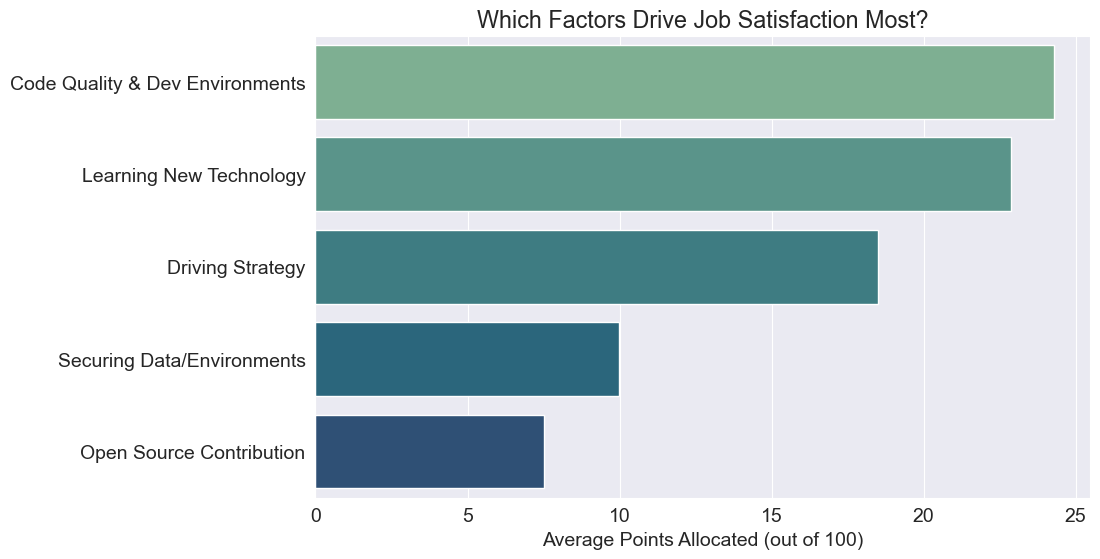

In [ ]:
jobsat_cols = ['JobSatPoints_1','JobSatPoints_4','JobSatPoints_5','JobSatPoints_6','JobSatPoints_7']
jobsat_labels = {
    'JobSatPoints_1': 'Driving Strategy',
    'JobSatPoints_4': 'Open Source Contribution',
    'JobSatPoints_5': 'Securing Data/Environments',
    'JobSatPoints_6': 'Code Quality & Dev Environments',
    'JobSatPoints_7': 'Learning New Technology',
}

avg_points = survey_df[jobsat_cols].mean().rename(jobsat_labels).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_points.values, y=avg_points.index, hue=avg_points.index, palette='crest', legend=False)
plt.xlabel('Average Points Allocated (out of 100)')
plt.ylabel('')
plt.title('Which Factors Drive Job Satisfaction Most?')
plt.show()

**Q: What matters most to developers in their day-to-day work?**
>
> **Finding:** "Learning New Technology" consistently ranks as the top satisfaction
> driver — developers fundamentally value growth and intellectual challenge.
> "Code Quality & Dev Environments" ranks second, reflecting that developers
> care deeply about the craft and the tools they use to practice it.
>
> "Open Source Contribution" typically ranks lowest — it matters to some,
> but is not a widespread primary driver.
>
> This has direct implications for retention: companies that invest in
> learning budgets, modern tooling, and high engineering standards retain
> developers more effectively than those offering higher salaries alone.
> Money is a hygiene factor; learning is a motivator.

### 2. Satisfaction Drivers Split by IC vs. Manager

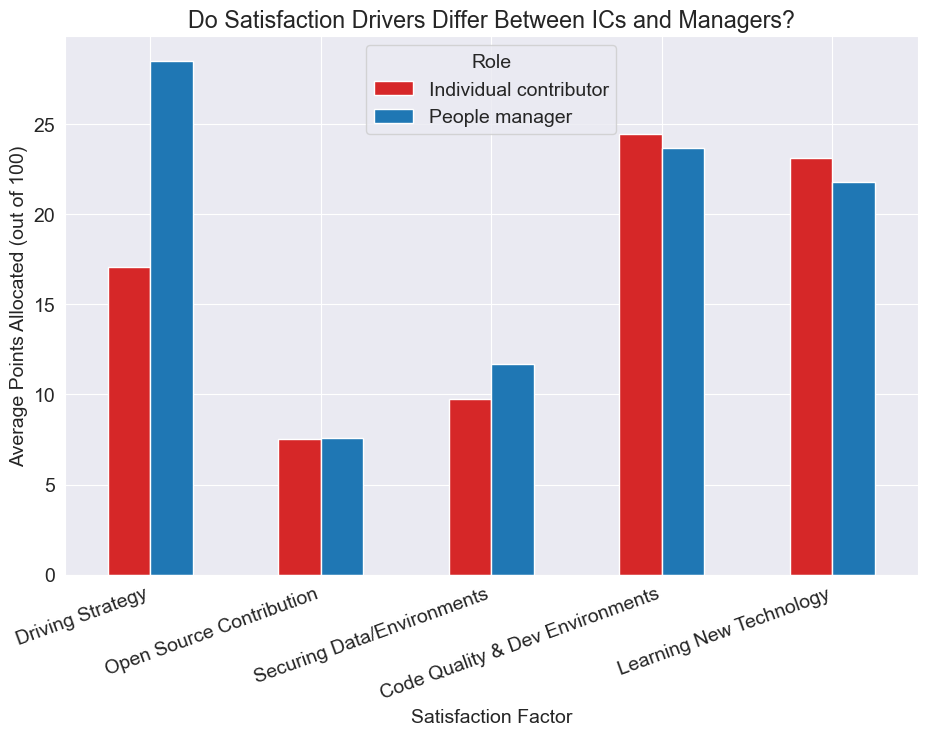

In [ ]:
survey_df['ICorPM'] = survey_df['ICorPM'].fillna('Unspecified')
ic_pm_df = survey_df[survey_df['ICorPM'] != 'Unspecified']

avg_by_role = ic_pm_df.groupby('ICorPM')[jobsat_cols].mean().rename(columns=jobsat_labels)

avg_by_role.T.plot(kind='bar', figsize=(11, 7), color=['#d62728', '#1f77b4'])
plt.xlabel('Satisfaction Factor')
plt.ylabel('Average Points Allocated (out of 100)')
plt.title('Do Satisfaction Drivers Differ Between ICs and Managers?')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Role')
plt.show()

**Q: Do people managers get satisfaction from different things than individual contributors?**
>
> **Finding:** Yes — with a meaningful and intuitive difference.
> Managers allocate more points to "Driving Strategy" than ICs do —
> the ability to influence direction is a core part of what managers
> find satisfying about their role. ICs, by contrast, allocate more
> points to "Learning New Technology" and "Code Quality" —
> the technical craft remains central to IC satisfaction.
>
> "Open Source Contribution" shows virtually no difference between roles —
> neither group prioritizes it highly.
>
> `.groupby('ICorPM').mean()` computes the average allocation per factor
> separately for each role. `.T` transposes the DataFrame so satisfaction
> factors appear on the x-axis and roles as the two colored bars.

### Combined Satisfaction Dashboard

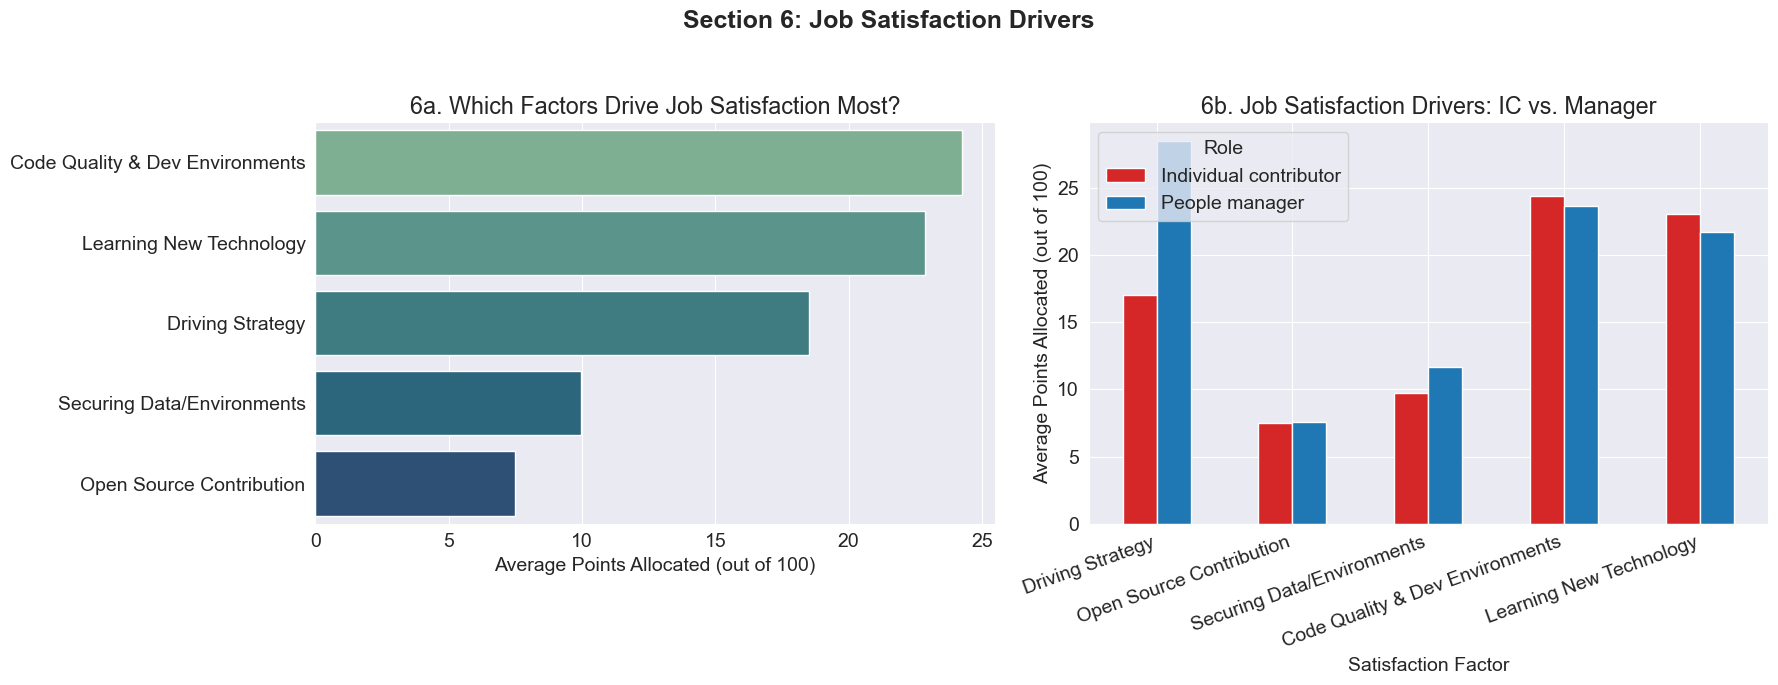

In [ ]:
jobsat_cols = ['JobSatPoints_1','JobSatPoints_4','JobSatPoints_5','JobSatPoints_6','JobSatPoints_7']
jobsat_labels = {
    'JobSatPoints_1': 'Driving Strategy',
    'JobSatPoints_4': 'Open Source Contribution',
    'JobSatPoints_5': 'Securing Data/Environments',
    'JobSatPoints_6': 'Code Quality & Dev Environments',
    'JobSatPoints_7': 'Learning New Technology',
}

# 6a data
avg_points = survey_df[jobsat_cols].mean().rename(jobsat_labels).sort_values(ascending=False)

# 6b data
survey_df['ICorPM'] = survey_df['ICorPM'].fillna('Unspecified')
ic_pm_df = survey_df[survey_df['ICorPM'] != 'Unspecified']
avg_by_role = ic_pm_df.groupby('ICorPM')[jobsat_cols].mean().rename(columns=jobsat_labels)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 6a — Overall ranking
sns.barplot(x=avg_points.values, y=avg_points.index, hue=avg_points.index, palette='crest', legend=False, ax=axes[0])
axes[0].set_title('6a. Which Factors Drive Job Satisfaction Most?')
axes[0].set_xlabel('Average Points Allocated (out of 100)')
axes[0].set_ylabel('')

# 6b — IC vs Manager comparison
avg_by_role.T.plot(kind='bar', ax=axes[1], color=['#d62728', '#1f77b4'])
axes[1].set_title('6b. Job Satisfaction Drivers: IC vs. Manager')
axes[1].set_xlabel('Satisfaction Factor')
axes[1].set_ylabel('Average Points Allocated (out of 100)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_xticklabels(axes[1].get_xticklabels(), ha='right')
axes[1].legend(title='Role')

fig.suptitle('Section 6: Job Satisfaction Drivers', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

> Two charts that tell the complete satisfaction story:
> what matters overall → and how that splits by career path.

# CONCLUSIONS

## Key Findings Summary
>
> After analyzing 65,000+ responses across six dimensions, here is what the data tells us:
>
> ---
>
> **1. Who developers are**
> The survey is dominated by 25-34 year olds (nearly 40% of respondents), with
> the US and India as the two largest country groups. Most developers hold
> Bachelor's degrees, but a meaningful proportion are self-taught or bootcamp-trained —
> this industry remains uniquely accessible without formal credentials.
>
> ---
>
> **2. What they use**
> Python and JavaScript dominate the language landscape. SQL ranks top 3-4
> consistently — it is not a niche data tool, it is a core developer skill.
> PostgreSQL has overtaken MySQL among professional developers. AWS leads cloud
> platforms by a significant margin, though Azure and GCP are closing the gap.
>
> ---
>
> **3. AI has crossed the mainstream threshold**
> Over 60% of developers now use AI tools in their workflow — not as experiments,
> but as regular parts of their process. Sentiment is broadly favorable across
> all experience levels. The nuanced finding: many developers who are positive
> about AI still acknowledge it poses some risk to job displacement — they hold
> both views simultaneously.
>
> ---
>
> **4. Remote work correlates with satisfaction, but moderately**
> Large enterprises (1,000+ employees) offer less remote flexibility than smaller
> companies. Remote workers report slightly higher job satisfaction than in-person
> workers, but the difference is modest — remote work alone does not explain
> satisfaction gaps.
>
> ---
>
> **5. Experience matters more than education for pay**
> Compensation rises sharply with experience in the first 0-10 years, then
> plateaus with enormous variance. Education adds a small premium at junior levels
> that nearly disappears at senior levels. Where you work (country) is the
> single largest predictor of compensation — a senior developer in the US
> earns 5-8x the median compensation of an equivalent developer in India.
>
> ---
>
> **6. Developers want to learn — more than anything else**
> "Learning New Technology" ranks as the top job satisfaction driver globally.
> Managers additionally value "Driving Strategy." Companies that invest in
> growth opportunities and engineering quality retain talent more effectively
> than those competing on salary alone.
>
> ---
>
> *Dataset: Stack Overflow Developer Survey 2024*
> *Analysis by: Harsh Kadam | github.com/harshskadam31*